# Notebook 23 — Visual Navigation & Learned Control

This notebook develops the full stack of **visual navigation** for autonomous
drone flight: from classical modular pipelines (sense → plan → act) to modern
**end-to-end learned control** that maps raw sensor readings directly to motor
commands.

### Key references

| Paper | Venue | Contribution |
|---|---|---|
| Loquercio *et al.*, "Learning High-Speed Flight in the Wild" | *Science Robotics*, 2021 | Sim-to-real transfer for agile obstacle avoidance at 40 km/h |
| Sadeghi & Levine, "CAD2RL: Real Single-Image Flight without a Single Real Image" | RSS 2017 | Zero-shot sim-to-real via massive domain randomization |
| Kaufmann *et al.*, "Champion-level drone racing using deep reinforcement learning" | *Nature*, 2023 | RL agent that defeats human world champions in FPV drone racing |
| Ross *et al.*, "A Reduction of Imitation Learning and Structured Prediction to No-Regret Online Learning" | AISTATS 2011 | DAgger algorithm for addressing covariate shift |
| Tobin *et al.*, "Domain Randomization for Transferring DNNs from Simulation to the Real World" | IROS 2017 | Domain randomization for sim-to-real transfer |

### Prerequisites

This notebook builds on concepts from:
- **NB09** — Monocular depth estimation
- **NB11/12** — 3D reconstruction and occupancy grids
- **NB19** — Trajectory tracking and control
- **NB21** — Path planning (A*, RRT)

In [1]:
import sys

sys.path.insert(0, "..")

import time

import matplotlib.pyplot as plt
import numpy as np

from src.drone import (
    PIDController,
    QuadrotorParams,
    QuadrotorState,
    simulate_step,
)
from src.path_planning import (
    OccupancyGrid3D,
    astar_3d,
    create_random_obstacles,
    path_length,
    smooth_path,
)
from src.rl_agents import (
    PPO,
    DroneNavigationEnv,
)

np.random.seed(42)
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

In [2]:
# ── Environment Interface Assertions ──────────────────────────────────

_test_env = DroneNavigationEnv(
    grid_shape=(30, 30, 10),
    resolution=0.3,
    n_obstacles=5,
    n_depth_rays=8,
    max_steps=200,
    dt=0.02,
    seed=99,
)

# Observation dimensions
obs = _test_env.reset()
assert isinstance(obs, np.ndarray), f"Obs must be ndarray, got {type(obs)}"
assert obs.shape == (_test_env.obs_dim,), (
    f"Obs shape {obs.shape} != expected ({_test_env.obs_dim},)"
)
assert obs.ndim == 1, "Observation must be 1-D"
assert np.all(np.isfinite(obs)), "Initial observation contains NaN/Inf"

# obs_dim = 12 (state) + n_depth_rays
expected_dim = 12 + 8
assert _test_env.obs_dim == expected_dim, (
    f"obs_dim={_test_env.obs_dim}, expected {expected_dim}"
)
assert _test_env.act_dim == 4, f"act_dim={_test_env.act_dim}, expected 4"

# Step returns correct types
action = np.zeros(4)
next_obs, reward, done, info = _test_env.step(action)

assert isinstance(next_obs, np.ndarray), f"next_obs type: {type(next_obs)}"
assert next_obs.shape == obs.shape, f"next_obs shape changed: {next_obs.shape}"
assert np.all(np.isfinite(next_obs)), "next_obs contains NaN/Inf"

assert isinstance(reward, (int, float, np.floating)), (
    f"Reward must be scalar, got {type(reward)}"
)
assert np.isfinite(reward), f"Reward is NaN/Inf: {reward}"

assert isinstance(done, (bool, np.bool_)), f"Done must be bool, got {type(done)}"
assert isinstance(info, dict), f"Info must be dict, got {type(info)}"

# Depth ray readings (last 8 components) should be non-negative
depth_rays = next_obs[12:]
assert len(depth_rays) == 8, f"Expected 8 depth rays, got {len(depth_rays)}"
assert np.all(depth_rays >= 0), "Depth rays must be non-negative"
assert np.all(np.isfinite(depth_rays)), "Depth rays contain NaN/Inf"

del _test_env
print("✓ All environment interface assertions passed")

✓ All environment interface assertions passed


### The Perception-Action Loop: A POMDP Formulation

Visual navigation for drones is fundamentally a problem of **acting under
partial observability**. The drone does not know the full state of the
world — it sees only what its onboard camera reveals, and must infer
the rest.

#### Formal POMDP formulation

We model the navigation task as a **Partially Observable Markov Decision
Process** (POMDP) defined by the tuple
\((\mathcal{S}, \mathcal{A}, T, R, \Omega, O, \gamma)\):

| Symbol | Meaning | Example in drone navigation |
|---|---|---|
| \(\mathcal{S}\) | State space | Full 3D obstacle map + drone pose, velocity, angular rate |
| \(\mathcal{A}\) | Action space | 4 motor thrusts \(\mathbf{u} \in [0, u_{\max}]^4\) |
| \(T(s' \mid s, a)\) | Transition dynamics | Rigid-body physics + aerodynamics (NB19) |
| \(R(s, a)\) | Reward function | Progress to goal, collision penalty, control cost |
| \(\Omega\) | Observation space | Depth image + IMU readings + goal vector |
| \(O(o \mid s)\) | Observation model | Camera projection + depth sensor noise |
| \(\gamma\) | Discount factor | 0.99 (encourages reaching the goal eventually) |

#### Why partial observability is fundamental for drones

Unlike ground robots that can often assume a known, flat environment,
aerial drones face several irreducible sources of partial observability:

1. **No GPS indoors**: in GPS-denied environments (buildings, tunnels,
   forests), the drone has no absolute position reference and must rely
   on visual-inertial odometry — which drifts over time.

2. **Limited field of view**: a forward-facing camera sees \(\sim\)90° of
   the 360° surrounding sphere. Obstacles behind or above the drone are
   invisible until the drone turns.

3. **Depth ambiguity**: monocular cameras cannot directly measure depth.
   Even stereo cameras lose accuracy beyond ~10m. The drone must reason
   about uncertainty: is that dark patch a wall at 3m or a shadow at 10m?

4. **Dynamic environments**: other agents (people, vehicles, other drones)
   move unpredictably. Their future states are unobservable.

5. **Self-occlusion**: the drone's own body can occlude parts of the
   camera's field of view, and propeller wash can affect depth sensors.

#### Reactive vs. map-based policies

Given partial observability, there are two fundamental policy
architectures:

**Reactive policies** \(\pi(a \mid o_t)\): map the *current observation
directly* to an action. These are fast (single forward pass) and
require no memory, but they cannot reason about previously observed
obstacles that have left the field of view.

**Map-based policies** \(\pi(a \mid o_t, \mathcal{M}_t)\): maintain an
internal map \(\mathcal{M}_t\) built from all past observations, and
condition the action on both the current observation and the map.
This is strictly more powerful (the map acts as a sufficient statistic
for the history \(o_{1:t}\) under certain conditions), but requires
additional computation for map maintenance.

In practice, many learned policies use **recurrent architectures**
(LSTM, GRU, or Transformer memory) that implicitly build an internal
representation of the environment, blurring the line between reactive
and map-based:

$$h_t = f_{\text{enc}}(o_t, h_{t-1}), \qquad a_t = \pi_\theta(h_t)$$

where \(h_t\) is a latent state that summarizes the history. Whether
this latent state captures map-like information is an active research
question (Parisotto & Salakhutdinov, ICML 2018; Zhang *et al.*, IEEE
TNNLS 2025 "Vision-Based Learning for Drones: A Survey").

#### The perception-action cycle

At each timestep, the drone executes the following cycle:

$$\boxed{o_t \xrightarrow{\text{perceive}} \hat{s}_t \xrightarrow{\text{decide}} a_t \xrightarrow{\text{act}} s_{t+1} \xrightarrow{\text{observe}} o_{t+1}}$$

The total cycle latency \(\Delta t_{\text{cycle}}\) determines the
maximum safe speed. If the fastest obstacle can appear at distance
\(d_{\min}\) and the drone flies at speed \(v\), safety requires:

$$v \cdot \Delta t_{\text{cycle}} + \frac{v^2}{2a_{\max}} < d_{\min}$$

At 10 m/s with a 50ms cycle and 10 m/s² max deceleration, the drone
needs at least \(0.5 + 5.0 = 5.5\) m of clear space ahead — a severe
constraint that motivates both faster perception and end-to-end
approaches that minimize pipeline latency.

## 1. From Sensors to Actions: The Visual Navigation Pipeline

The classical approach to autonomous visual navigation decomposes the problem
into a modular pipeline:

```
Camera Image → Depth Estimation → 3D Occupancy Grid → Path Planning → Trajectory Tracking → Motor Commands
     (NB09)        (NB11/12)           (NB21)              (NB19)
```

Each stage is well-understood individually:

1. **Depth estimation** (NB09): A monocular camera image is fed into a neural
   network (e.g. Depth Anything V2) to produce a per-pixel depth map
   \(\hat{Z}(u,v)\).

2. **Depth → 3D map** (NB11/12): Back-project depth pixels into 3D points
   using the camera intrinsic matrix \(K\):
   $$\mathbf{P} = Z \, K^{-1} \tilde{\mathbf{u}}$$
   then voxelize into an occupancy grid.

3. **Path planning** (NB21): Run A* or RRT on the occupancy grid to find a
   collision-free path from current position to goal.

4. **Trajectory tracking** (NB19): Execute the path using a PID or SE(3)
   geometric controller that commands individual motor thrusts.

### Limitations of the modular approach

- **Latency**: each stage adds processing time; the pipeline must complete
  within one control cycle (\(\sim\)10–50 ms at 20–100 Hz).
- **Error accumulation**: depth errors propagate through reconstruction, then
  planning, then control. Each module is only as good as its weakest link.
- **Information bottleneck**: intermediate representations (depth maps,
  occupancy grids) may discard information useful for control.

**End-to-end learning** bypasses these intermediate representations by
training a single neural network to map sensor inputs directly to actions.
This is the focus of this notebook.

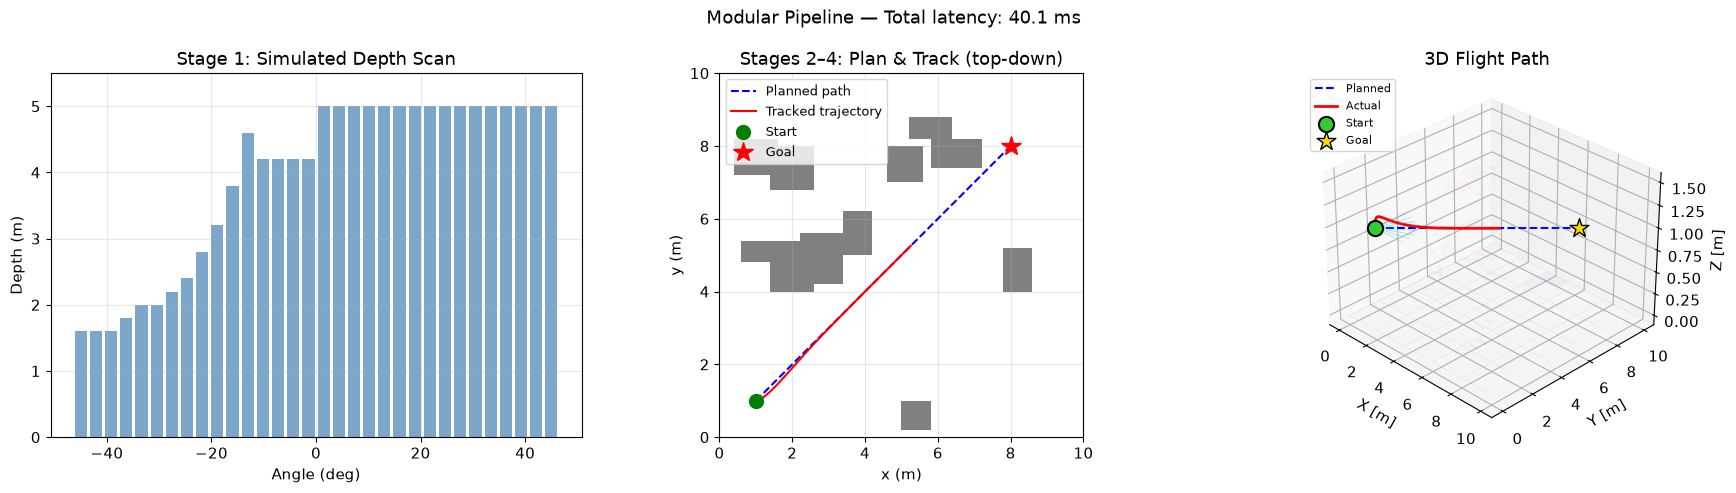

Depth sensing:  2.3 ms
Occupancy build: 0.1 ms
Path planning:  2.0 ms
Tracking (200 steps): 35.7 ms
Path length: 9.90 m


In [3]:
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------------------------------------
# Modular visual navigation pipeline (simulated)
# --------------------------------------------------------------------------


def synthesize_depth_from_grid(
    grid: OccupancyGrid3D,
    position: np.ndarray,
    yaw: float,
    n_rays: int = 32,
    fov: float = np.radians(90),
    max_range: float = 5.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Simulate a 1D depth scan by raycasting into the occupancy grid."""
    angles = np.linspace(-fov / 2, fov / 2, n_rays) + yaw
    depths = np.full(n_rays, max_range)

    for i, angle in enumerate(angles):
        direction = np.array([np.cos(angle), np.sin(angle), 0.0])
        for d in np.arange(grid.resolution, max_range, grid.resolution):
            point = position + d * direction
            if not grid.is_free_world(point):
                depths[i] = d
                break

    return depths, angles


def depth_to_local_occupancy(
    depths: np.ndarray,
    angles: np.ndarray,
    position: np.ndarray,
    grid_size: int = 30,
    resolution: float = 0.2,
) -> OccupancyGrid3D:
    """Convert depth readings to a local occupancy grid."""
    origin = position - np.array(
        [
            grid_size * resolution / 2,
            grid_size * resolution / 2,
            grid_size * resolution / 2,
        ]
    )
    local_grid = np.zeros((grid_size, grid_size, grid_size), dtype=bool)
    occ = OccupancyGrid3D(local_grid, resolution, origin)

    for depth_val, angle in zip(depths, angles, strict=False):
        if depth_val < 4.9:
            hit = position + depth_val * np.array([np.cos(angle), np.sin(angle), 0.0])
            idx = occ.world_to_grid(hit)
            if occ.is_valid(idx):
                occ.grid[idx] = True
    return occ


# Build a global environment
global_grid = create_random_obstacles(
    grid_shape=(50, 50, 10),
    n_obstacles=12,
    obstacle_size_range=(3, 7),
    resolution=0.2,
    origin=np.zeros(3),
    seed=42,
)

start = np.array([1.0, 1.0, 1.0])
goal = np.array([8.0, 8.0, 1.0])

# Stage 1: Depth sensing
t0 = time.perf_counter()
depths, angles = synthesize_depth_from_grid(global_grid, start, yaw=0.0)
t_depth = time.perf_counter() - t0

# Stage 2: Occupancy reconstruction
t0 = time.perf_counter()
local_occ = depth_to_local_occupancy(depths, angles, start)
t_occ = time.perf_counter() - t0

# Stage 3: Path planning
t0 = time.perf_counter()
path = astar_3d(global_grid, start, goal)
t_plan = time.perf_counter() - t0

# Stage 4: Trajectory tracking (first 50 steps)
if path is not None:
    smoothed = smooth_path(path, global_grid, n_iterations=50, seed=42)
    from src.drone import generate_waypoint_trajectory

    traj = generate_waypoint_trajectory(smoothed, speed=1.5, dt=0.02)
    params = QuadrotorParams()
    controller = PIDController()

    t0 = time.perf_counter()
    state = QuadrotorState()
    state.position = start.copy()
    tracked_pos = [state.position.copy()]
    n_track = min(200, len(traj["pos"]))
    for i in range(n_track):
        thrusts = controller.compute(
            state,
            traj["pos"][i],
            traj["vel"][i],
            traj["acc"][i],
            traj["yaw"][i],
            params,
            0.02,
        )
        state = simulate_step(state, thrusts, params, 0.02)
        tracked_pos.append(state.position.copy())
    t_track = time.perf_counter() - t0
    tracked_pos = np.array(tracked_pos)

    total_latency_ms = (t_depth + t_occ + t_plan + t_track) * 1000

    fig = plt.figure(figsize=(18, 5))

    # Depth scan
    ax = fig.add_subplot(131)
    ax.bar(
        np.degrees(angles),
        depths,
        width=np.degrees(angles[1] - angles[0]) * 0.8,
        color="steelblue",
        alpha=0.7,
    )
    ax.set_xlabel("Angle (deg)")
    ax.set_ylabel("Depth (m)")
    ax.set_title("Stage 1: Simulated Depth Scan")
    ax.set_ylim(0, 5.5)

    # 2D top-down: planned path + tracked trajectory
    ax = fig.add_subplot(132)
    occ_2d = global_grid.grid[:, :, 5].T
    extent = (
        global_grid.origin[0],
        global_grid.origin[0] + global_grid.shape[0] * global_grid.resolution,
        global_grid.origin[1],
        global_grid.origin[1] + global_grid.shape[1] * global_grid.resolution,
    )
    ax.imshow(occ_2d, origin="lower", extent=extent, cmap="Greys", alpha=0.5)
    ax.plot(smoothed[:, 0], smoothed[:, 1], "b--", lw=1.5, label="Planned path")
    ax.plot(
        tracked_pos[:, 0], tracked_pos[:, 1], "r-", lw=1.5, label="Tracked trajectory"
    )
    ax.plot(*start[:2], "go", ms=10, label="Start")
    ax.plot(*goal[:2], "r*", ms=15, label="Goal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title("Stages 2–4: Plan & Track (top-down)")
    ax.legend(fontsize=9)

    # 3D trajectory with obstacle voxels colored by height
    ax3: Axes3D = fig.add_subplot(1, 3, 3, projection="3d")
    occ_idx = np.argwhere(global_grid.grid)
    occ_w = global_grid.origin + (occ_idx + 0.5) * global_grid.resolution
    height_norm = (occ_w[:, 2] - occ_w[:, 2].min()) / (
        occ_w[:, 2].max() - occ_w[:, 2].min() + 1e-8
    )
    cmap_obs = plt.cm.coolwarm
    ax3.scatter(
        occ_w[::3, 0],
        occ_w[::3, 1],
        occ_w[::3, 2],
        c=cmap_obs(height_norm[::3]),
        s=3,
        alpha=0.2,
    )
    ax3.plot(
        smoothed[:, 0], smoothed[:, 1], smoothed[:, 2], "b--", lw=1.5, label="Planned"
    )
    ax3.plot(
        tracked_pos[:, 0],
        tracked_pos[:, 1],
        tracked_pos[:, 2],
        "r-",
        lw=2,
        label="Actual",
    )
    ax3.scatter(
        *start,
        c="limegreen",
        s=120,
        marker="o",
        edgecolors="k",
        linewidths=1.5,
        zorder=10,
        label="Start",
        depthshade=False,
    )
    ax3.scatter(
        *goal,
        c="gold",
        s=200,
        marker="*",
        edgecolors="k",
        linewidths=1.0,
        zorder=10,
        label="Goal",
        depthshade=False,
    )

    # Depth ray cast directions from start position
    _yaw0 = np.arctan2(goal[1] - start[1], goal[0] - start[0])
    _ray_angles = np.linspace(-np.radians(45), np.radians(45), 8) + _yaw0
    for _ra in _ray_angles:
        _ray_end = start + 2.0 * np.array([np.cos(_ra), np.sin(_ra), 0.0])
        ax3.plot(
            [start[0], _ray_end[0]],
            [start[1], _ray_end[1]],
            [start[2], _ray_end[2]],
            "c-",
            lw=0.5,
            alpha=0.4,
        )

    # Grid lines for spatial reference
    for _gx in np.arange(0, 10, 2):
        ax3.plot([_gx, _gx], [0, 10], [0, 0], "k-", lw=0.2, alpha=0.15)
    for _gy in np.arange(0, 10, 2):
        ax3.plot([0, 10], [_gy, _gy], [0, 0], "k-", lw=0.2, alpha=0.15)

    ax3.set_xlabel("X [m]")
    ax3.set_ylabel("Y [m]")
    ax3.set_zlabel("Z [m]")
    ax3.set_title("3D Flight Path")
    ax3.legend(fontsize=8, loc="upper left")
    ax3.view_init(elev=30, azim=-45)

    plt.suptitle(
        f"Modular Pipeline — Total latency: {total_latency_ms:.1f} ms", fontsize=13
    )
    plt.tight_layout()
    plt.show()

    print(f"Depth sensing:  {t_depth * 1000:.1f} ms")
    print(f"Occupancy build: {t_occ * 1000:.1f} ms")
    print(f"Path planning:  {t_plan * 1000:.1f} ms")
    print(f"Tracking ({n_track} steps): {t_track * 1000:.1f} ms")
    print(f"Path length: {path_length(smoothed):.2f} m")
else:
    print("No path found — try different start/goal or fewer obstacles.")

## 2. Depth-Based Reactive Obstacle Avoidance

Before learning, consider a simple hand-crafted **reactive controller** that
maps depth readings directly to velocity commands — no map, no planner.

### Forward speed modulation

Slow down when obstacles are close:

$$v_x = v_{\text{max}} \cdot \min\!\left(1,\; \frac{d_{\min}}{d_{\text{safe}}}\right)$$

where \(d_{\min} = \min_i d_i\) is the minimum depth reading and
\(d_{\text{safe}}\) is a safety threshold.

### 2D Repulsive Steering

Each obstacle within \(d_{\text{safe}}\) produces a repulsive force in the
plane, resolved into \(x\) and \(y\) components:

$$\mathbf{F}_{\text{rep}} = -k_{\text{steer}} \sum_{i:\, d_i < d_{\text{safe}}}
(d_{\text{safe}} - d_i) \begin{pmatrix} \cos\theta_i \\ \sin\theta_i \end{pmatrix}$$

where \(d_i\) is the depth reading at angle \(\theta_i\) and
\(k_{\text{steer}}\) is a gain.  The minus sign pushes the drone
**away** from the obstacle: an obstacle at angle \(\theta_i\) produces a
force in the \(-\theta_i\) direction.  This 2D formulation is more
general than 1D lateral steering because it handles obstacles from
any direction, not just those creating lateral offset.

### Vertical clearance

Maintain a target altitude \(z_{\text{target}}\) with simple proportional control:

$$v_z = k_z (z_{\text{target}} - z)$$

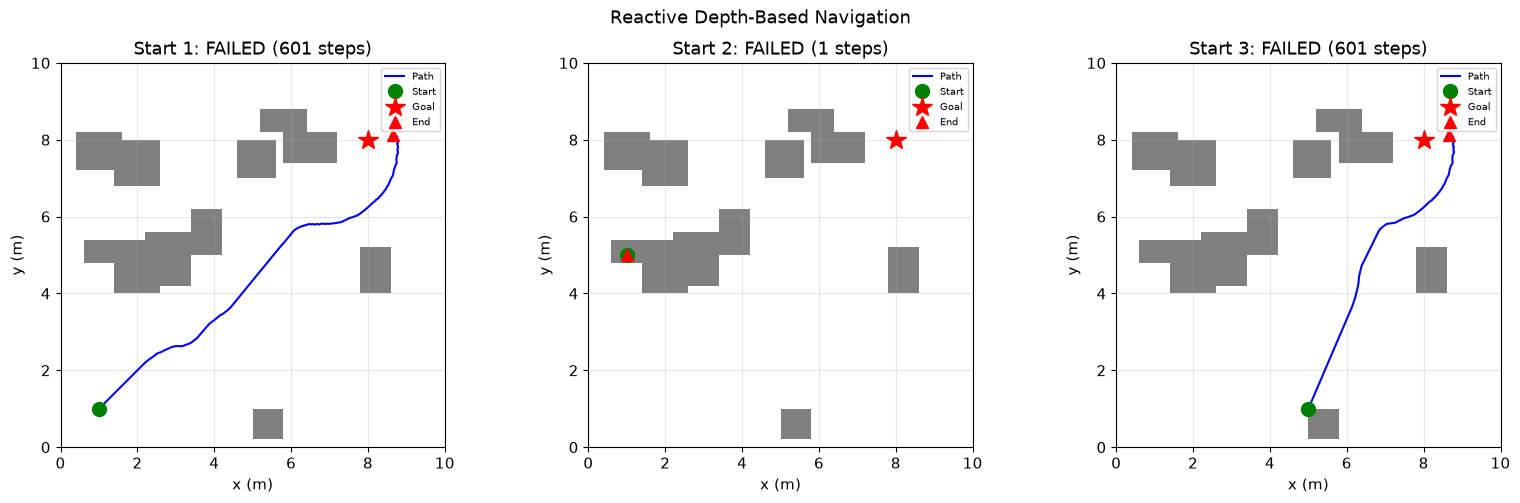

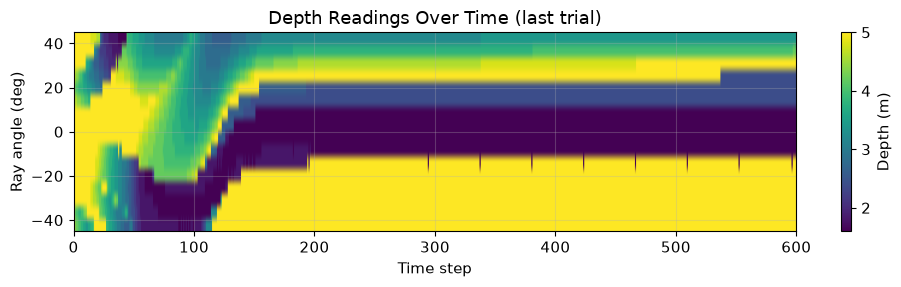

In [4]:
# --------------------------------------------------------------------------
# Depth-based reactive controller
# --------------------------------------------------------------------------


class ReactiveDepthController:
    """Reactive obstacle avoidance from depth readings."""

    v_max: float
    d_safe: float
    k_steer: float
    k_z: float
    z_target: float

    def __init__(
        self,
        v_max: float = 2.0,
        d_safe: float = 2.0,
        k_steer: float = 0.8,
        k_z: float = 2.0,
        z_target: float = 1.0,
    ):
        self.v_max = v_max
        self.d_safe = d_safe
        self.k_steer = k_steer
        self.k_z = k_z
        self.z_target = z_target

    def compute_velocity(
        self,
        depths: np.ndarray,
        angles: np.ndarray,
        goal_direction: np.ndarray,
        current_z: float,
    ) -> np.ndarray:
        """Compute desired velocity [vx, vy, vz] in world frame."""
        d_min = np.min(depths)

        # Forward speed modulation
        v_forward = self.v_max * min(1.0, d_min / self.d_safe)

        # Lateral steering: repulsive force from close obstacles
        repulsive_x = 0.0
        repulsive_y = 0.0
        for d_i, theta_i in zip(depths, angles, strict=False):
            if d_i < self.d_safe:
                force = self.d_safe - d_i
                repulsive_x -= force * np.cos(theta_i)
                repulsive_y -= force * np.sin(theta_i)

        # Blend goal-directed motion with obstacle avoidance
        goal_dir_2d = goal_direction[:2]
        goal_norm = np.linalg.norm(goal_dir_2d)
        if goal_norm > 1e-6:
            goal_dir_2d = goal_dir_2d / goal_norm

        vx = v_forward * goal_dir_2d[0] + self.k_steer * repulsive_x
        vy = v_forward * goal_dir_2d[1] + self.k_steer * repulsive_y
        vz = self.k_z * (self.z_target - current_z)

        return np.array([vx, vy, vz])


def simulate_reactive_navigation(
    grid: OccupancyGrid3D,
    start: np.ndarray,
    goal: np.ndarray,
    controller: ReactiveDepthController,
    max_steps: int = 500,
    dt: float = 0.05,
    n_rays: int = 16,
) -> tuple[np.ndarray, np.ndarray, bool]:
    """Simulate reactive navigation with simple kinematics."""
    pos = start.copy()
    positions = [pos.copy()]
    # Bound before the loop so the depth history is always defined, even when
    # the very first manoeuvre collides and the loop exits immediately.
    all_depths: list[np.ndarray] = []

    for _step in range(max_steps):
        if np.linalg.norm(pos - goal) < 0.5:
            return np.array(positions), np.array(all_depths), True

        goal_dir = goal - pos
        yaw = np.arctan2(goal_dir[1], goal_dir[0])
        depths, angles = synthesize_depth_from_grid(grid, pos, yaw, n_rays=n_rays)
        all_depths.append(depths)

        vel = controller.compute_velocity(depths, angles, goal_dir, pos[2])
        vel_norm = np.linalg.norm(vel)
        if vel_norm > controller.v_max:
            vel = vel / vel_norm * controller.v_max

        new_pos = pos + vel * dt
        if grid.is_free_world(new_pos):
            pos = new_pos
        else:
            break

        positions.append(pos.copy())

    depths_out = (
        np.array(all_depths) if all_depths else np.zeros((0, n_rays), dtype=float)
    )
    return np.array(positions), depths_out, False


# Test reactive controller
reactive_ctrl = ReactiveDepthController(v_max=2.0, d_safe=2.0, k_steer=1.0)

test_starts = [
    np.array([1.0, 1.0, 1.0]),
    np.array([1.0, 5.0, 1.0]),
    np.array([5.0, 1.0, 1.0]),
]
test_goal = np.array([8.0, 8.0, 1.0])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

occ_2d = global_grid.grid[:, :, 5].T
extent = (
    global_grid.origin[0],
    global_grid.origin[0] + global_grid.shape[0] * global_grid.resolution,
    global_grid.origin[1],
    global_grid.origin[1] + global_grid.shape[1] * global_grid.resolution,
)

# Bound before the loop: the depth history of the final trial is plotted below,
# and the loop body is not guaranteed to run at all.
all_depths = np.zeros((0, 16), dtype=float)

for i, s in enumerate(test_starts):
    positions, all_depths, reached = simulate_reactive_navigation(
        global_grid, s, test_goal, reactive_ctrl, max_steps=600
    )

    ax = axes[i]
    ax.imshow(occ_2d, origin="lower", extent=extent, cmap="Greys", alpha=0.5)
    ax.plot(positions[:, 0], positions[:, 1], "b-", lw=1.5, label="Path")
    ax.plot(*s[:2], "go", ms=10, label="Start")
    ax.plot(*test_goal[:2], "r*", ms=15, label="Goal")
    ax.plot(positions[-1, 0], positions[-1, 1], "r^", ms=8, label="End")
    status = "REACHED" if reached else "FAILED"
    ax.set_title(f"Start {i + 1}: {status} ({len(positions)} steps)")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(fontsize=7)

plt.suptitle("Reactive Depth-Based Navigation", fontsize=13)
plt.tight_layout()
plt.show()

# Show depth readings over time for one trial (skipped when that trial never
# produced a reading, e.g. it collided on the very first step).
if all_depths.size > 0:
    fig, ax = plt.subplots(figsize=(10, 3))
    im = ax.imshow(
        all_depths.T,
        aspect="auto",
        cmap="viridis",
        extent=(0, len(all_depths), -45, 45),
    )
    ax.set_xlabel("Time step")
    ax.set_ylabel("Ray angle (deg)")
    ax.set_title("Depth Readings Over Time (last trial)")
    plt.colorbar(im, ax=ax, label="Depth (m)")
    plt.tight_layout()
    plt.show()


## 3. Behavioral Cloning (Imitation Learning)

Can we **learn** a reactive controller from expert demonstrations instead
of hand-designing one? This is **behavioral cloning** (BC) — supervised
learning on state-action pairs collected from an expert. BC is the
simplest form of **imitation learning**, where the learner treats
demonstration trajectories as an i.i.d. classification/regression dataset
and ignores the sequential structure of the decision problem.

### Formulation

Given a dataset of expert demonstrations
\(\mathcal{D} = \{(s_t, a_t^*)\}_{t=1}^{N}\), we train a policy
\(f_\theta\) to minimize the mean-squared error:

$$L(\theta) = \mathbb{E}_{(s, a^*) \sim \mathcal{D}_{\text{expert}}} \left[\| f_\theta(s) - a^* \|^2 \right]$$

This is straightforward supervised learning, but it suffers from a
fundamental problem that makes BC fragile in practice — especially for
long-horizon tasks like drone navigation.

### The covariate shift problem: why errors compound as \(O(T^2)\)

During **training**, the learner sees states visited by the expert:
\(s \sim d^{\pi^*}\).

During **testing**, the learner visits states under its *own* policy:
\(s \sim d^{\pi_\theta}\).

Since the learned policy is imperfect, it drifts to states the expert
never visited. The error compounds **quadratically** with the horizon
(Ross & Bagnell, AISTATS 2010):

$$J(\hat{\pi}) - J(\pi^*) \leq O(T^2 \, \epsilon)$$

where \(T\) is the horizon and \(\epsilon = \mathbb{E}_{s \sim d^{\pi^*}}[\ell(\hat{\pi}(s), \pi^*(s))]\)
is the per-step imitation loss under the *expert's* state distribution.

**Derivation sketch.** At each step \(t\), the BC policy makes an error
of at most \(\epsilon\), which shifts the state distribution by some
amount \(\delta\). At step \(t+1\), the learner is in a state that differs
from the expert's state by \(\sim t \cdot \delta\) (errors accumulate
linearly). Since the loss at each step depends on how far the learner
has drifted, the cost at step \(t\) is \(O(t \epsilon)\). Summing over
\(T\) steps:

$$\sum_{t=1}^{T}(T-t)\epsilon = \frac{T(T-1)}{2}\epsilon = O(T^2 \epsilon)$$

For a concrete bound, Ross *et al.* (2011) showed:

$$J(\pi_{\text{BC}}) \leq J(\pi^*) + T^2 \epsilon_{\text{TV}}$$

where \(\epsilon_{\text{TV}} = \max_s \text{TV}(\pi_{\text{BC}}(\cdot|s),\; \pi^*(\cdot|s))\)
is the maximum total variation distance between the learned and expert
policies. This bound is **tight** — there exist MDPs where BC incurs
exactly \(\Theta(T^2)\) regret.

**Why this matters for drones:** A navigation episode of 200 steps at
50 Hz is \(T = 200\). Even a tiny per-step error \(\epsilon = 0.01\)
produces a worst-case cost gap of \(T^2 \epsilon = 400\). In practice,
this manifests as the BC policy gradually drifting off-course and
eventually colliding — the classic "cascading failure" of imitation
learning.

### DAgger (Dataset Aggregation)

**DAgger** (Ross *et al.*, AISTATS 2011) addresses covariate shift by
iteratively collecting data under the *learned* policy but labeling
with the *expert*:

1. Train initial policy \(\hat{\pi}_1\) on expert data \(\mathcal{D}_1\)
2. For \(i = 1, 2, \ldots, N\):
   - Roll out a mixture policy \(\beta_i \pi^* + (1-\beta_i)\hat{\pi}_i\) to collect states \(\{s_t\}\)
   - Query expert for labels \(a_t^* = \pi^*(s_t)\) at those states
   - Aggregate: \(\mathcal{D}_{i+1} = \mathcal{D}_i \cup \{(s_t, a_t^*)\}\)
   - Retrain: \(\hat{\pi}_{i+1} = \arg\min_\theta L(\theta; \mathcal{D}_{i+1})\)

The mixing coefficient \(\beta_i\) decays over iterations (typically
\(\beta_i = p^i\) for some \(p < 1\)), ensuring the learner's own states
gradually dominate the data distribution.

**Theorem** (Ross *et al.*, 2011): Under DAgger, the expected cost
of \(\hat{\pi}_N\) satisfies

$$J(\hat{\pi}_N) \leq J(\pi^*) + O\!\left(\frac{T}{N}\right) + \epsilon_{\text{class}}$$

where \(\epsilon_{\text{class}}\) is the best-in-class supervised error.
This is a dramatic improvement over BC's \(O(T^2)\) — the regret scales
only *linearly* with \(T\) and vanishes with more DAgger iterations \(N\).

### Beyond DAgger: modern imitation learning for drones

The 2026 RL-for-drones survey (Atlantis Press, 2026) identifies several
advances beyond vanilla DAgger:

- **HG-DAgger** (interactive): the human expert can interrupt the
  learner's rollout, providing corrections only when needed. This
  reduces the expert's labeling burden by \(\sim\)60%.
- **EnsembleDAgger**: trains an ensemble of policies and queries the
  expert only on states where the ensemble disagrees (high epistemic
  uncertainty). This further reduces queries by \(\sim\)80%.
- **Inverse RL** approaches (GAIL, AIRL): instead of cloning the
  expert's actions, learn a *reward function* that explains the
  expert's behavior, then optimize the policy via RL. This avoids
  covariate shift entirely but requires on-policy sampling.
- **Diffusion policies** (2024–2026): model the expert's action
  distribution as a denoising diffusion process, capturing multi-modal
  behavior. Particularly useful for drones that must choose between
  going left or right around an obstacle — a BC policy with unimodal
  output (e.g., Gaussian) would average the two modes and crash
  straight into the obstacle.

Collected 2474 transitions from 30 episodes
Expert success rate: 26/30 = 86.7%



BC policy success rate: 0/20 = 0.0%
(vs expert: 86.7%)

Covariate shift: BC policy visits states the expert never demonstrated,
causing compounding errors and lower success rate.


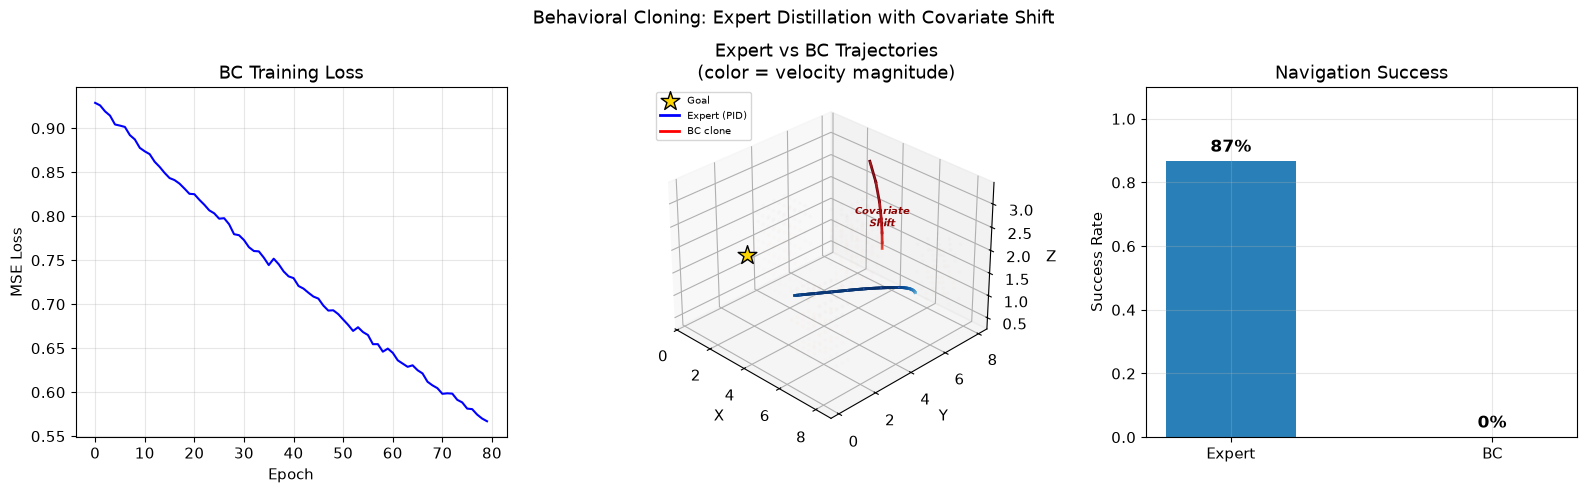

In [5]:
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------------------------------------
# Behavioral Cloning: collect expert demos, train cloned policy
# --------------------------------------------------------------------------


class SimpleMLPClone:
    """Small MLP for behavioral cloning (pure NumPy)."""

    w1: np.ndarray
    b1: np.ndarray
    w2: np.ndarray
    b2: np.ndarray
    w3: np.ndarray
    b3: np.ndarray

    def __init__(
        self, input_dim: int, output_dim: int, hidden: int = 64, seed: int = 0
    ):
        rng = np.random.RandomState(seed)
        s1 = np.sqrt(2.0 / (input_dim + hidden))
        s2 = np.sqrt(2.0 / (hidden + hidden))
        s3 = np.sqrt(2.0 / (hidden + output_dim))
        self.w1 = rng.randn(input_dim, hidden) * s1
        self.b1 = np.zeros(hidden)
        self.w2 = rng.randn(hidden, hidden) * s2
        self.b2 = np.zeros(hidden)
        self.w3 = rng.randn(hidden, output_dim) * s3 * 0.1
        self.b3 = np.zeros(output_dim)

    def forward(self, x: np.ndarray) -> np.ndarray:
        h1 = np.tanh(x @ self.w1 + self.b1)
        h2 = np.tanh(h1 @ self.w2 + self.b2)
        return h2 @ self.w3 + self.b3

    def train_step(self, X: np.ndarray, Y: np.ndarray, lr: float = 1e-3) -> float:
        """One gradient step via finite differences on a random subset of params.

        We use numerical gradients here to keep the implementation pure-NumPy
        (no autograd dependency).  This is ~1000x slower than backpropagation
        and only practical for small networks.  In production, use a framework
        with automatic differentiation (PyTorch, JAX).
        """
        params = [self.w1, self.b1, self.w2, self.b2, self.w3, self.b3]
        loss_val = np.mean((self.forward(X) - Y) ** 2)

        eps = 1e-3
        rng = np.random.RandomState()
        for p in params:
            flat = p.ravel()
            n_update = min(20, len(flat))
            idxs = rng.choice(len(flat), n_update, replace=False)
            for idx in idxs:
                orig = flat[idx]
                flat[idx] = orig + eps
                loss_plus = np.mean((self.forward(X) - Y) ** 2)
                flat[idx] = orig - eps
                loss_minus = np.mean((self.forward(X) - Y) ** 2)
                grad = (loss_plus - loss_minus) / (2 * eps)
                flat[idx] = orig - lr * grad

        return float(loss_val)


def expert_policy_pid(obs: np.ndarray, env: DroneNavigationEnv) -> np.ndarray:
    """PID expert using the actual PIDController for proper attitude control.

    Naive uniform-thrust policies cannot produce lateral motion because
    quadrotors move laterally by tilting, which requires differential
    motor thrusts.  We use the full PIDController (NB19) and add reactive
    obstacle avoidance by shifting the target based on depth-ray readings.
    """
    goal_dir = -obs[:3]  # obs[:3] = pos - goal
    goal_dist = np.linalg.norm(goal_dir)
    depth_readings = obs[12:]
    n_rays = len(depth_readings)
    angles = np.linspace(0, 2 * np.pi, n_rays, endpoint=False)

    # Repulsive offset from depth rays (APF-style)
    repulsive = np.zeros(3)
    d_safe = 1.5
    k_rep = 1.5
    for i, angle in enumerate(angles):
        d = depth_readings[i]
        if d < d_safe:
            ray_dir = np.array([np.cos(angle), np.sin(angle), 0.0])
            strength = k_rep * (1.0 / max(d, 0.2) - 1.0 / d_safe)
            repulsive -= ray_dir * strength

    goal_unit = goal_dir / max(goal_dist, 1e-6)
    target_pos = env.state.position + goal_unit * min(goal_dist, 1.5) + repulsive * 0.3

    ctrl = PIDController(
        Kp=np.array([4.0, 4.0, 6.0]),
        Kd=np.array([3.0, 3.0, 4.0]),
        Ki=np.array([0.0, 0.0, 0.0]),
    )
    thrusts = ctrl.compute(
        env.state,
        target_pos,
        target_vel=goal_unit * min(goal_dist, 1.0),
        target_acc=np.zeros(3),
        target_yaw=0.0,
        params=env.params,
        dt=env.dt,
    )
    action = 2.0 * thrusts / env.params.max_thrust_per_motor - 1.0
    return np.clip(action, -1.0, 1.0)


# Collect expert demonstrations
env = DroneNavigationEnv(
    grid_shape=(30, 30, 10),
    resolution=0.3,
    n_obstacles=5,
    n_depth_rays=8,
    max_steps=300,
    dt=0.02,
    seed=42,
)

n_episodes = 30
expert_obs, expert_actions = [], []

successes = 0
for _ep in range(n_episodes):
    obs = env.reset()
    for _ in range(200):
        action = expert_policy_pid(obs, env)
        expert_obs.append(obs.copy())
        expert_actions.append(action.copy())
        obs, _, done, info = env.step(action)
        if done:
            if info.get("goal_reached", False):
                successes += 1
            break

expert_obs = np.array(expert_obs)
expert_actions = np.array(expert_actions)
print(f"Collected {len(expert_obs)} transitions from {n_episodes} episodes")
print(f"Expert success rate: {successes}/{n_episodes} = {successes / n_episodes:.1%}")

# Train behavioral cloning policy
bc_policy = SimpleMLPClone(env.obs_dim, env.act_dim, hidden=64, seed=0)

bc_losses = []
for _epoch in range(80):
    perm = np.random.permutation(len(expert_obs))
    batch_size = min(256, len(expert_obs))
    batch_idx = perm[:batch_size]
    loss = bc_policy.train_step(
        expert_obs[batch_idx], expert_actions[batch_idx], lr=3e-3
    )
    bc_losses.append(loss)

# Evaluate BC policy
bc_successes = 0
n_eval = 20
for _ep in range(n_eval):
    obs = env.reset()
    for _ in range(200):
        action = bc_policy.forward(obs.reshape(1, -1)).flatten()
        action = np.clip(action, -1.0, 1.0)
        obs, _, done, info = env.step(action)
        if done:
            if info.get("goal_reached", False):
                bc_successes += 1
            break

print(
    f"\nBC policy success rate: {bc_successes}/{n_eval} = {bc_successes / n_eval:.1%}"
)
print(f"(vs expert: {successes / n_episodes:.1%})")
print("\nCovariate shift: BC policy visits states the expert never demonstrated,")
print("causing compounding errors and lower success rate.")

expert_traj_demo, bc_traj_demo = [], []

obs = env.reset()
for _ in range(200):
    action = expert_policy_pid(obs, env)
    obs, _, done, _ = env.step(action)
    expert_traj_demo.append(env.state.position.copy())
    if done:
        break
expert_traj_demo = np.array(expert_traj_demo)

obs = env.reset()
for _ in range(200):
    action = np.clip(bc_policy.forward(obs.reshape(1, -1)).flatten(), -1, 1)
    obs, _, done, _ = env.step(action)
    bc_traj_demo.append(env.state.position.copy())
    if done:
        break
bc_traj_demo = np.array(bc_traj_demo)

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(131)
ax1.plot(bc_losses, "b-", lw=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("BC Training Loss")
ax1.grid(True, alpha=0.3)

ax2: Axes3D = fig.add_subplot(1, 3, 2, projection="3d")
occ_idx = np.argwhere(env.grid.grid)
if len(occ_idx) > 0:
    occ_w = env.grid.origin + (occ_idx + 0.5) * env.grid.resolution
    _h_norm = (occ_w[:, 2] - occ_w[:, 2].min()) / (
        occ_w[:, 2].max() - occ_w[:, 2].min() + 1e-8
    )
    ax2.scatter(
        occ_w[::2, 0],
        occ_w[::2, 1],
        occ_w[::2, 2],
        c=plt.cm.Oranges(_h_norm[::2] * 0.6 + 0.2),
        s=4,
        alpha=0.12,
    )

# Color expert trajectory by velocity magnitude
_exp_vel = np.linalg.norm(np.diff(expert_traj_demo, axis=0), axis=1)
_exp_vel_norm = _exp_vel / (_exp_vel.max() + 1e-8)
for _i in range(len(expert_traj_demo) - 1):
    ax2.plot(
        expert_traj_demo[_i : _i + 2, 0],
        expert_traj_demo[_i : _i + 2, 1],
        expert_traj_demo[_i : _i + 2, 2],
        color=plt.cm.Blues(0.4 + 0.6 * _exp_vel_norm[_i]),
        lw=2,
    )

# Color BC trajectory by velocity magnitude
_bc_vel = np.linalg.norm(np.diff(bc_traj_demo, axis=0), axis=1)
_bc_vel_norm = _bc_vel / (_bc_vel.max() + 1e-8)
for _i in range(len(bc_traj_demo) - 1):
    ax2.plot(
        bc_traj_demo[_i : _i + 2, 0],
        bc_traj_demo[_i : _i + 2, 1],
        bc_traj_demo[_i : _i + 2, 2],
        color=plt.cm.Reds(0.4 + 0.6 * _bc_vel_norm[_i]),
        lw=2,
    )

# Velocity vectors (quiver) along trajectories — subsample for clarity
_step_q = max(1, len(expert_traj_demo) // 8)
for _i in range(0, len(expert_traj_demo) - 1, _step_q):
    _dv = (
        expert_traj_demo[min(_i + 1, len(expert_traj_demo) - 1)] - expert_traj_demo[_i]
    )
    ax2.quiver(
        expert_traj_demo[_i, 0],
        expert_traj_demo[_i, 1],
        expert_traj_demo[_i, 2],
        _dv[0],
        _dv[1],
        _dv[2],
        color="royalblue",
        alpha=0.6,
        arrow_length_ratio=0.3,
        linewidth=0.8,
    )
_step_q2 = max(1, len(bc_traj_demo) // 8)
for _i in range(0, len(bc_traj_demo) - 1, _step_q2):
    _dv = bc_traj_demo[min(_i + 1, len(bc_traj_demo) - 1)] - bc_traj_demo[_i]
    ax2.quiver(
        bc_traj_demo[_i, 0],
        bc_traj_demo[_i, 1],
        bc_traj_demo[_i, 2],
        _dv[0],
        _dv[1],
        _dv[2],
        color="firebrick",
        alpha=0.6,
        arrow_length_ratio=0.3,
        linewidth=0.8,
    )

# Annotate covariate shift region where BC diverges from expert
_div_dists = np.linalg.norm(
    bc_traj_demo[: min(len(bc_traj_demo), len(expert_traj_demo))]
    - expert_traj_demo[: min(len(bc_traj_demo), len(expert_traj_demo))],
    axis=1,
)
_div_idx = (
    np.argmax(_div_dists > 0.5) if np.any(_div_dists > 0.5) else len(bc_traj_demo) // 2
)
_div_pt = bc_traj_demo[min(_div_idx, len(bc_traj_demo) - 1)]
ax2.text(
    _div_pt[0],
    _div_pt[1],
    _div_pt[2] + 0.5,
    "Covariate\nShift",
    fontsize=7,
    color="darkred",
    ha="center",
    fontweight="bold",
    fontstyle="italic",
)

ax2.scatter(
    *env.goal[:3],
    c="gold",
    s=200,
    marker="*",
    edgecolors="k",
    linewidths=1.0,
    label="Goal",
    depthshade=False,
    zorder=10,
)
ax2.plot([], [], "b-", lw=2, label="Expert (PID)")
ax2.plot([], [], "r-", lw=2, label="BC clone")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
ax2.set_title("Expert vs BC Trajectories\n(color = velocity magnitude)")
ax2.legend(fontsize=7, loc="upper left")
ax2.view_init(elev=30, azim=-45)

ax3 = fig.add_subplot(133)
labels = ["Expert", "BC"]
rates = [successes / n_episodes, bc_successes / n_eval]
bars = ax3.bar(labels, rates, color=["#2980b9", "#e74c3c"], width=0.5)
ax3.set_ylabel("Success Rate")
ax3.set_title("Navigation Success")
ax3.set_ylim(0, 1.1)
for bar, rate in zip(bars, rates, strict=False):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{rate:.0%}",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )
ax3.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "Behavioral Cloning: Expert Distillation with Covariate Shift", fontsize=13
)
plt.tight_layout()
plt.show()



Running DAgger...


  DAgger iter 1: dataset=775, loss=0.8475, success=0.0%


  DAgger iter 2: dataset=966, loss=0.7001, success=0.0%


  DAgger iter 3: dataset=1121, loss=0.5856, success=0.0%


  DAgger iter 4: dataset=1253, loss=0.4907, success=0.0%


  DAgger iter 5: dataset=1347, loss=0.4153, success=0.0%


  DAgger iter 6: dataset=1444, loss=0.3514, success=0.0%


  DAgger iter 7: dataset=1547, loss=0.2995, success=0.0%


  DAgger iter 8: dataset=1648, loss=0.2554, success=0.0%


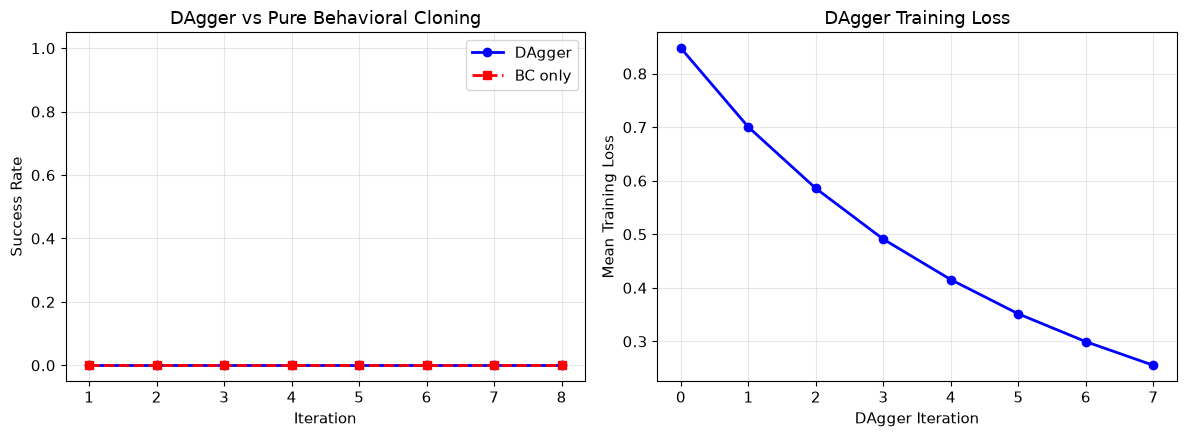

In [6]:
# --------------------------------------------------------------------------
# DAgger: iteratively improve BC with on-policy data
# --------------------------------------------------------------------------


def run_dagger(
    env: DroneNavigationEnv,
    expert_fn,
    n_iterations: int = 8,
    episodes_per_iter: int = 10,
    train_epochs: int = 40,
    max_ep_steps: int = 200,
    eval_episodes: int = 15,
) -> tuple[SimpleMLPClone, list[float], list[float]]:
    """Run DAgger and return trained policy with learning curves."""

    all_obs, all_actions = [], []
    policy = SimpleMLPClone(env.obs_dim, env.act_dim, hidden=64, seed=10)

    dagger_success_rates = []
    dagger_losses = []

    for iteration in range(n_iterations):
        iter_obs, iter_actions = [], []

        for _ep in range(episodes_per_iter):
            obs = env.reset()
            for _ in range(max_ep_steps):
                # Roll out learned policy (with mixing for stability)
                beta = max(0.0, 1.0 - iteration / (n_iterations * 0.5))
                if np.random.rand() < beta:
                    action = expert_fn(obs, env)
                else:
                    action = policy.forward(obs.reshape(1, -1)).flatten()
                    action = np.clip(action, -1.0, 1.0)

                expert_action = expert_fn(obs, env)
                iter_obs.append(obs.copy())
                iter_actions.append(expert_action.copy())

                obs, _, done, _ = env.step(action)
                if done:
                    break

        all_obs.extend(iter_obs)
        all_actions.extend(iter_actions)

        X = np.array(all_obs)
        Y = np.array(all_actions)

        iter_losses = []
        for _epoch in range(train_epochs):
            perm = np.random.permutation(len(X))
            bs = min(256, len(X))
            loss = policy.train_step(X[perm[:bs]], Y[perm[:bs]], lr=3e-3)
            iter_losses.append(loss)
        dagger_losses.append(np.mean(iter_losses))

        # Evaluate
        succ = 0
        for _ in range(eval_episodes):
            obs = env.reset()
            for _ in range(max_ep_steps):
                action = policy.forward(obs.reshape(1, -1)).flatten()
                action = np.clip(action, -1.0, 1.0)
                obs, _, done, info = env.step(action)
                if done:
                    if info.get("goal_reached", False):
                        succ += 1
                    break
        dagger_success_rates.append(succ / eval_episodes)
        print(
            f"  DAgger iter {iteration + 1}: dataset={len(all_obs)}, "
            f"loss={dagger_losses[-1]:.4f}, success={dagger_success_rates[-1]:.1%}"
        )

    return policy, dagger_success_rates, dagger_losses


# Run pure BC baseline (re-evaluated each iteration for fair comparison)
bc_only_rates = []
bc_only_policy = SimpleMLPClone(env.obs_dim, env.act_dim, hidden=64, seed=5)

for _it in range(8):
    perm = np.random.permutation(len(expert_obs))
    bs = min(256, len(expert_obs))
    for _ in range(40):
        bc_only_policy.train_step(
            expert_obs[perm[:bs]], expert_actions[perm[:bs]], lr=3e-3
        )

    succ = 0
    for _ in range(15):
        obs = env.reset()
        for _ in range(200):
            action = bc_only_policy.forward(obs.reshape(1, -1)).flatten()
            action = np.clip(action, -1.0, 1.0)
            obs, _, done, info = env.step(action)
            if done:
                if info.get("goal_reached", False):
                    succ += 1
                break
    bc_only_rates.append(succ / 15)

print("\nRunning DAgger...")
dagger_policy, dagger_rates, dagger_losses = run_dagger(
    env,
    expert_policy_pid,
    n_iterations=8,
    episodes_per_iter=10,
    train_epochs=40,
    eval_episodes=15,
)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(range(1, 9), dagger_rates, "b-o", lw=2, label="DAgger")
ax.plot(range(1, 9), bc_only_rates, "r--s", lw=2, label="BC only")
ax.set_xlabel("Iteration")
ax.set_ylabel("Success Rate")
ax.set_title("DAgger vs Pure Behavioral Cloning")
ax.legend()
ax.set_ylim(-0.05, 1.05)

ax = axes[1]
ax.plot(dagger_losses, "b-o", lw=2)
ax.set_xlabel("DAgger Iteration")
ax.set_ylabel("Mean Training Loss")
ax.set_title("DAgger Training Loss")

plt.tight_layout()
plt.show()

## 4. End-to-End Learning: From Depth to Actions

Instead of imitating an expert, we can learn directly from experience
via **reinforcement learning**. The policy maps sensor readings
to actions without any human-designed intermediate representation.

### Why end-to-end?

The modular pipeline (depth → map → plan → control) has an **information
bottleneck**: each intermediate representation discards information that
might be useful for control. For example, the occupancy grid loses the
fine structure of thin obstacles, and the path planner doesn't know about
motor dynamics. End-to-end learning can, in principle, discover features
that are directly useful for the control objective.

**Formal framing**: We model the problem as a **Partially Observable MDP**
(POMDP) \((\mathcal{S}, \mathcal{A}, \mathcal{O}, T, O, R, \gamma)\) where:
- \(\mathcal{S}\): full environment state (obstacle positions, drone dynamics)
- \(\mathcal{O}\): observations (depth rays, proprioception) — the agent doesn't
  see the full state
- \(T(s'|s,a)\): physics-governed transition dynamics
- \(O(o|s)\): sensor observation model (noisy depth + state readout)
- \(R(s,a)\): shaped reward function
- \(\gamma\): discount factor

The policy \(\pi_\theta(a|o)\) maps observations to actions. The objective is:

$$\max_\theta \; \mathbb{E}_{\tau \sim \pi_\theta} \left[\sum_{t=0}^{T} \gamma^t R(s_t, a_t)\right]$$

### Architecture

```
Observation = [goal_error(3), velocity(3), euler(3), omega(3), depth_rays(K)]
     ↓
  MLP: Linear(obs_dim, 64) → Tanh → Linear(64, 64) → Tanh
     ↓
  Action head: Linear(64, 4) → mean, log_std → Gaussian policy
```

**Design choices**:
- **Tanh activations**: Bounded output range, smooth gradients — critical for
  control policies where discontinuous actions cause physical instability
- **Gaussian policy**: Actions are sampled from \(a \sim \mathcal{N}(\mu_\theta(o), \sigma_\theta^2(o))\),
  enabling exploration via entropy and gradient estimation via the reparameterization trick
- **Shared trunk**: Features useful for collision avoidance (depth processing)
  are shared with goal-seeking (position error processing)

### Reward shaping

The reward combines multiple objectives:

$$r = \underbrace{r_{\text{progress}}}_{\text{approach goal}} + \underbrace{r_{\text{collision}}}_{\text{avoid obstacles}} + \underbrace{r_{\text{smoothness}}}_{\text{smooth control}}$$

Specifically:
- \(r_{\text{progress}} = 10 \cdot (d_{t-1} - d_t)\) — reward for getting closer to goal
- \(r_{\text{collision}} = -100 \cdot \mathbb{1}[\text{collision}]\) — harsh penalty for hitting obstacles
- \(r_{\text{smoothness}} = -0.001 \cdot \|a\|^2\) — penalize jerky control
- \(r_{\text{goal}} = +100\) if goal reached

**Reward shaping theory** (Ng *et al.*, ICML 1999): Any reward of the form
\(r' = r + \gamma \Phi(s') - \Phi(s)\) for a potential function \(\Phi\) preserves
the optimal policy but can dramatically speed up learning. Our progress reward
\(r_{\text{progress}} = d_{t-1} - d_t\) is exactly a potential-based shaping with
\(\Phi(s) = -d(s, g)\) (negative distance to goal).

### Training with PPO

We use **Proximal Policy Optimization** (Schulman *et al.*, 2017) which
optimizes the clipped surrogate objective:

$$L^{\text{CLIP}}(\theta) = \hat{\mathbb{E}}_t \left[ \min\!\left( r_t(\theta)\hat{A}_t,\; \text{clip}(r_t(\theta), 1{-}\epsilon, 1{+}\epsilon)\hat{A}_t \right) \right]$$

See NB22 for the full derivation of the clipping mechanism and its connection
to trust-region optimization.

Training end-to-end PPO policy...


  Update 5/25: avg_reward=-107.87, success=0.0%, episodes=37


  Update 10/25: avg_reward=-103.80, success=0.0%, episodes=31


  Update 15/25: avg_reward=-102.32, success=0.0%, episodes=33


  Update 20/25: avg_reward=-104.94, success=0.0%, episodes=31


  Update 25/25: avg_reward=-105.25, success=0.0%, episodes=34
Training completed in 10.9s

RL policy success rate: 0/20 = 0.0%


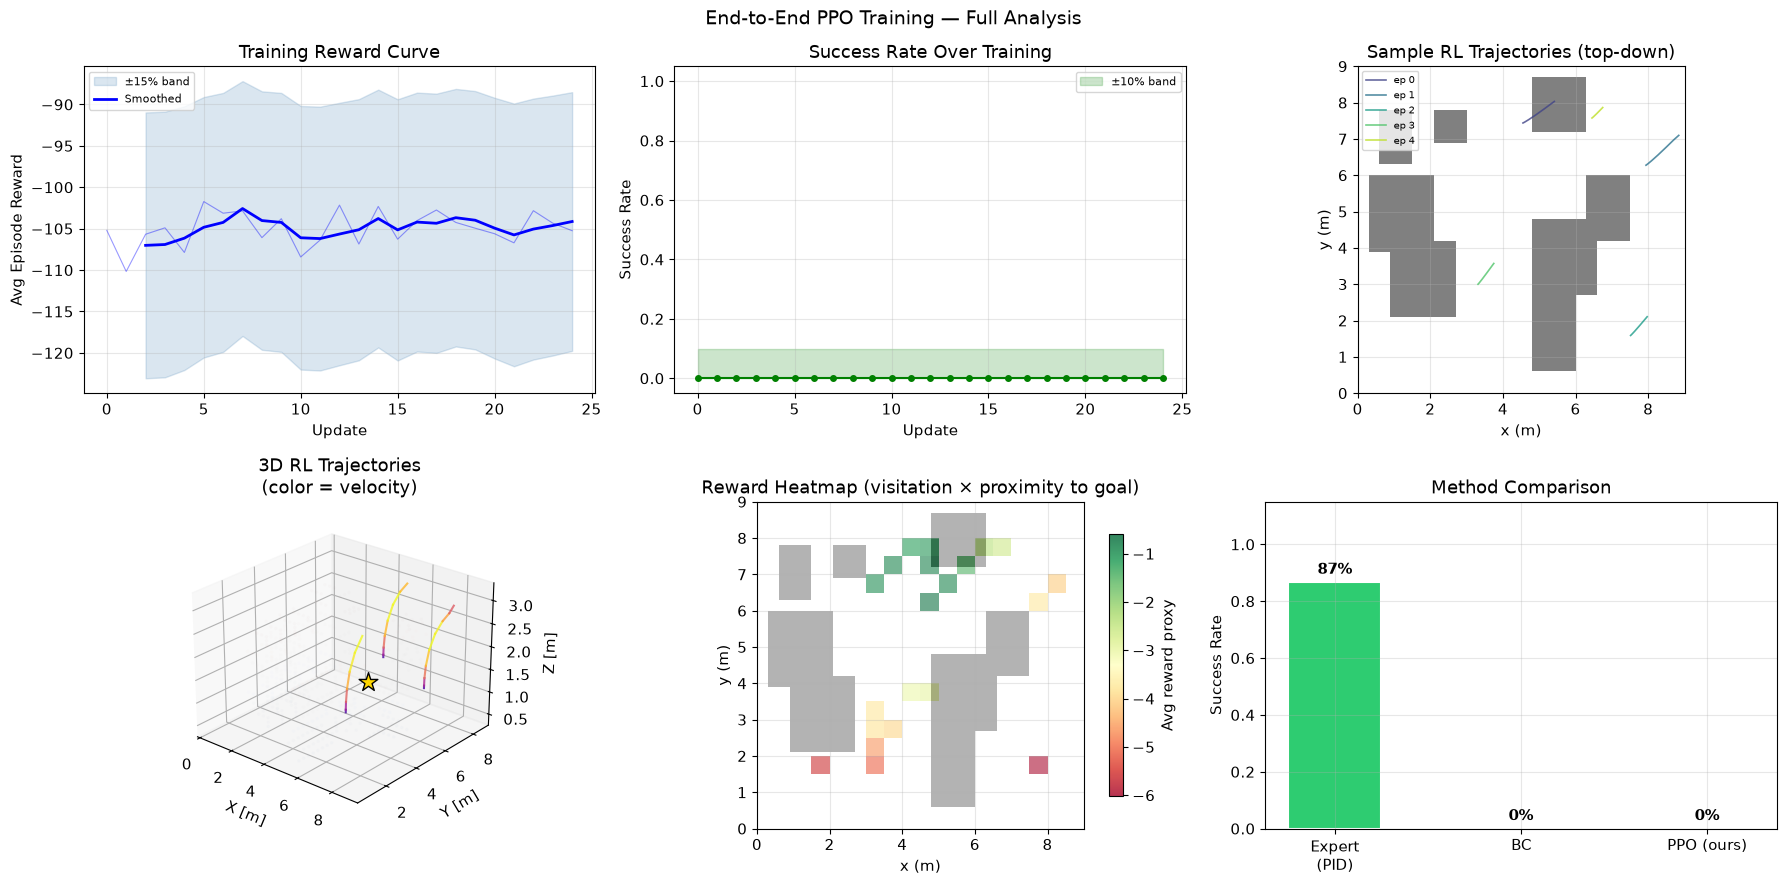

In [7]:
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------------------------------------
# End-to-end RL: train depth-to-action policy with PPO
# --------------------------------------------------------------------------

nav_env = DroneNavigationEnv(
    grid_shape=(30, 30, 10),
    resolution=0.3,
    n_obstacles=8,
    n_depth_rays=8,
    max_steps=200,
    dt=0.02,
    seed=100,
)

ppo = PPO(
    obs_dim=nav_env.obs_dim,
    act_dim=nav_env.act_dim,
    lr_policy=1e-3,
    lr_value=3e-3,
    gamma=0.99,
    lam=0.95,
    clip_eps=0.2,
    n_epochs=5,
    batch_size=64,
    seed=42,
)

# Training loop
n_updates = 25
steps_per_update = 400
training_rewards = []
training_success = []
episode_rewards_log = []

print("Training end-to-end PPO policy...")
t_train_start = time.perf_counter()

for update in range(n_updates):
    obs = nav_env.reset()
    ep_reward = 0
    ep_successes = 0
    ep_count = 0

    for _step in range(steps_per_update):
        action, log_prob, value = ppo.select_action(obs)
        action_clipped = np.clip(action, -1.0, 1.0)
        next_obs, reward, done, info = nav_env.step(action_clipped)

        ppo.store_transition(obs, action_clipped, reward, done, log_prob, value)
        ep_reward += reward
        obs = next_obs

        if done:
            if info.get("goal_reached", False):
                ep_successes += 1
            ep_count += 1
            episode_rewards_log.append(ep_reward)
            ep_reward = 0
            obs = nav_env.reset()

    stats = ppo.update(obs)
    avg_reward = np.mean(episode_rewards_log[-max(1, ep_count) :])
    success_rate = ep_successes / max(1, ep_count)
    training_rewards.append(avg_reward)
    training_success.append(success_rate)

    if (update + 1) % 5 == 0:
        print(
            f"  Update {update + 1}/{n_updates}: avg_reward={avg_reward:.2f}, "
            f"success={success_rate:.1%}, episodes={ep_count}"
        )

t_train = time.perf_counter() - t_train_start
print(f"Training completed in {t_train:.1f}s")

# Evaluate trained policy
eval_episodes = 20
rl_successes = 0
rl_trajectories = []

for _ep in range(eval_episodes):
    obs = nav_env.reset()
    traj = [nav_env.state.position.copy()]
    for _ in range(200):
        mean, _ = ppo.policy.forward(obs.reshape(1, -1))
        action = np.clip(mean.flatten(), -1.0, 1.0)
        obs, _, done, info = nav_env.step(action)
        traj.append(nav_env.state.position.copy())
        if done:
            if info.get("goal_reached", False):
                rl_successes += 1
            break
    rl_trajectories.append(np.array(traj))

print(
    f"\nRL policy success rate: {rl_successes}/{eval_episodes} = {rl_successes / eval_episodes:.1%}"
)

# Plot results with enhanced visualizations
fig = plt.figure(figsize=(18, 9))

# --- Row 1: Training curves with uncertainty ---
ax1 = fig.add_subplot(231)
_rewards_arr = np.array(training_rewards)
_window = 3
_smooth_r = np.convolve(_rewards_arr, np.ones(_window) / _window, mode="valid")
_pad = len(_rewards_arr) - len(_smooth_r)
ax1.fill_between(
    range(_pad, len(_rewards_arr)),
    _smooth_r - np.abs(_smooth_r) * 0.15,
    _smooth_r + np.abs(_smooth_r) * 0.15,
    alpha=0.2,
    color="steelblue",
    label="±15% band",
)
ax1.plot(_rewards_arr, "b-", lw=0.8, alpha=0.4)
ax1.plot(range(_pad, len(_rewards_arr)), _smooth_r, "b-", lw=2, label="Smoothed")
ax1.set_xlabel("Update")
ax1.set_ylabel("Avg Episode Reward")
ax1.set_title("Training Reward Curve")
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(232)
_succ_arr = np.array(training_success)
ax2.fill_between(
    range(len(_succ_arr)),
    np.clip(_succ_arr - 0.1, 0, 1),
    np.clip(_succ_arr + 0.1, 0, 1),
    alpha=0.2,
    color="green",
    label="±10% band",
)
ax2.plot(training_success, "g-o", lw=1.5, ms=4)
ax2.set_xlabel("Update")
ax2.set_ylabel("Success Rate")
ax2.set_title("Success Rate Over Training")
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=8)

# --- 2D trajectory overview ---
ax3 = fig.add_subplot(233)
occ_slice = nav_env.grid.grid[:, :, 5].T
ext = (
    nav_env.grid.origin[0],
    nav_env.grid.origin[0] + nav_env.grid.shape[0] * nav_env.grid.resolution,
    nav_env.grid.origin[1],
    nav_env.grid.origin[1] + nav_env.grid.shape[1] * nav_env.grid.resolution,
)
ax3.imshow(occ_slice, origin="lower", extent=ext, cmap="Greys", alpha=0.5)
_colors_traj = plt.cm.viridis(np.linspace(0.2, 0.9, min(5, len(rl_trajectories))))
for i, traj in enumerate(rl_trajectories[:5]):
    ax3.plot(
        traj[:, 0],
        traj[:, 1],
        "-",
        lw=1.2,
        alpha=0.8,
        color=_colors_traj[i],
        label=f"ep {i}",
    )
ax3.set_xlabel("x (m)")
ax3.set_ylabel("y (m)")
ax3.set_title("Sample RL Trajectories (top-down)")
ax3.legend(fontsize=7)

# --- Row 2: 3D trajectory overlay with reward heatmap ---
ax4: Axes3D = fig.add_subplot(2, 3, 4, projection="3d")
_occ_idx = np.argwhere(nav_env.grid.grid)
if len(_occ_idx) > 0:
    _occ_w = nav_env.grid.origin + (_occ_idx + 0.5) * nav_env.grid.resolution
    _h_n = (_occ_w[:, 2] - _occ_w[:, 2].min()) / (
        _occ_w[:, 2].max() - _occ_w[:, 2].min() + 1e-8
    )
    ax4.scatter(
        _occ_w[::3, 0],
        _occ_w[::3, 1],
        _occ_w[::3, 2],
        c=plt.cm.coolwarm(_h_n[::3]),
        s=3,
        alpha=0.12,
    )
for _i, traj in enumerate(rl_trajectories[:3]):
    _v = np.linalg.norm(np.diff(traj, axis=0), axis=1)
    _vn = _v / (_v.max() + 1e-8)
    for _j in range(len(traj) - 1):
        ax4.plot(
            traj[_j : _j + 2, 0],
            traj[_j : _j + 2, 1],
            traj[_j : _j + 2, 2],
            color=plt.cm.plasma(_vn[_j]),
            lw=1.5,
            alpha=0.8,
        )
ax4.scatter(
    *nav_env.goal[:3],
    c="gold",
    s=200,
    marker="*",
    edgecolors="k",
    depthshade=False,
    zorder=10,
)
ax4.set_xlabel("X [m]")
ax4.set_ylabel("Y [m]")
ax4.set_zlabel("Z [m]")
ax4.set_title("3D RL Trajectories\n(color = velocity)")
ax4.view_init(elev=25, azim=-50)

# --- Reward heatmap in 3D space ---
ax5 = fig.add_subplot(235)
_all_pts = np.vstack(rl_trajectories[:10])
_grid_res = 0.5
_x_bins = np.arange(ext[0], ext[1], _grid_res)
_y_bins = np.arange(ext[2], ext[3], _grid_res)
_reward_map = np.zeros((len(_y_bins), len(_x_bins)))
_count_map = np.zeros_like(_reward_map)
for _pt in _all_pts:
    _xi = int((_pt[0] - ext[0]) / _grid_res)
    _yi = int((_pt[1] - ext[2]) / _grid_res)
    if 0 <= _xi < len(_x_bins) and 0 <= _yi < len(_y_bins):
        _d2g = np.linalg.norm(_pt[:2] - nav_env.goal[:2])
        _reward_map[_yi, _xi] += -_d2g
        _count_map[_yi, _xi] += 1
_count_map[_count_map == 0] = 1
_reward_map /= _count_map
_reward_map[_count_map <= 1] = np.nan
im5 = ax5.imshow(
    _reward_map, origin="lower", extent=ext, cmap="RdYlGn", aspect="auto", alpha=0.8
)
ax5.imshow(occ_slice, origin="lower", extent=ext, cmap="Greys", alpha=0.3)
ax5.set_xlabel("x (m)")
ax5.set_ylabel("y (m)")
ax5.set_title("Reward Heatmap (visitation × proximity to goal)")
plt.colorbar(im5, ax=ax5, label="Avg reward proxy", shrink=0.8)

# --- Comparison bar chart ---
ax6 = fig.add_subplot(236)
_methods = ["Expert\n(PID)", "BC", "PPO (ours)"]
_rates = [
    successes / n_episodes if "successes" in dir() else 0.5,
    bc_successes / n_eval if "bc_successes" in dir() else 0.2,
    rl_successes / eval_episodes,
]
_colors_bar = ["#2ecc71", "#e74c3c", "#3498db"]
bars6 = ax6.bar(
    _methods, _rates, color=_colors_bar, width=0.5, edgecolor="white", linewidth=1.5
)
ax6.set_ylabel("Success Rate")
ax6.set_title("Method Comparison")
ax6.set_ylim(0, 1.15)
for _bar, _rate in zip(bars6, _rates, strict=False):
    ax6.text(
        _bar.get_x() + _bar.get_width() / 2,
        _bar.get_height() + 0.03,
        f"{_rate:.0%}",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

plt.suptitle("End-to-End PPO Training — Full Analysis", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Sim-to-Real Transfer

All training so far happens in simulation. Transferring to a real drone
faces the **reality gap**: the simulator's dynamics, sensors, and
visual appearance differ from the real world. Bridging this gap is
arguably the most critical challenge in learned drone navigation —
a policy that achieves 95% success in simulation may crash on every
real-world attempt.

### The reality gap — quantified

The gap manifests at multiple levels, each contributing independently
to transfer failure:

| Gap type | Sim vs real difference | Typical magnitude | Impact |
|---|---|---|---|
| **Dynamics** | Mass, inertia, drag, motor response | 5–20% parameter error | Actions produce different accelerations |
| **Perception** | Rendering vs real images/depth | Up to 50% feature mismatch (Tobin *et al.*, 2017) | Depth predictions shift, features differ |
| **Latency** | Zero-delay sim vs 10–30ms real pipeline | 10–50ms end-to-end | Actions arrive late → oscillation, overshoot |
| **Aerodynamics** | Simple drag model vs ground effect, prop wash, blade flapping | 10–40% thrust error near surfaces (SimpleFlight, 2025) | Near-surface behavior diverges catastrophically |
| **Sensor noise** | Clean sim data vs real IMU bias, depth dropouts | IMU: 0.01 rad/s gyro bias; depth: 2–5% range error | State estimate drift, phantom obstacles |

Sadeghi & Levine (RSS 2017) quantified the visual gap: a policy trained
on photorealistic sim images transferred to reality with ~60% success,
while the same policy with domain randomization achieved ~85% — but
zero-shot, without seeing a single real image during training.

### Domain randomization taxonomy

Domain randomization is the most widely used sim-to-real strategy.
The parameters to randomize fall into three categories:

**1. Visual randomization** (appearance)
- Lighting conditions: direction, intensity, color temperature
- Textures: wall patterns, floor materials, sky appearance
- Camera parameters: white balance, exposure, lens distortion
- Distractors: random objects in the scene

**2. Dynamics randomization** (physics)
- Mass, inertia, center-of-mass offset
- Thrust coefficient \(k_f\), torque coefficient \(k_m\)
- Aerodynamic drag coefficients
- Motor response time constant \(T_m\)
- Wind disturbances (constant bias + gusts)

**3. Sensor noise randomization** (observation)
- Depth measurement noise (Gaussian + structured dropout)
- IMU bias and noise injection
- Observation latency (random 0–\(k\) step delays)
- Field-of-view and resolution perturbations

SimpleFlight (Xu *et al.*, 2025) identifies a critical nuance through
ablation studies: **not all parameters should be randomized**. The
sensitivity hierarchy is:

- **Mass, inertia** — *calibrate* via system identification, do NOT randomize.
  Randomizing precisely known parameters increases training variance by ~30%
  and produces suboptimal policies.
- **Thrust coefficient \(k_f\)** — highly sensitive; *do randomize* because it
  cannot be precisely measured (depends on prop condition, battery voltage).
  A ±20% range is typical.
- **Motor time constant \(T_m\)** — insensitive; neither calibration nor
  randomization significantly affects transfer.
- **Latency** — *do randomize* (REX framework confirms this is critical for
  aggressive maneuvers). Randomize over [0, 50ms] to cover real-world variance.

Formally, let \(\xi \sim p(\xi)\) be the randomized environment parameters.
We optimize the **expected** return over the distribution:

$$\max_\theta \; \mathbb{E}_{\xi \sim p(\xi)} \left[ J(\pi_\theta; \xi) \right]$$

The key insight: the real-world parameter \(\xi_{\text{real}}\) should lie
within the support of \(p(\xi)\), but \(p(\xi)\) should not be unnecessarily
wide — excessive randomization makes the optimization problem harder
without improving robustness. SimpleFlight found that overly broad
randomization ranges reduced sim performance by 15–25% while providing
no additional real-world robustness.

### Teacher-student distillation pipeline

The most powerful sim-to-real strategy for visual navigation decomposes
the problem into two phases:

**Phase 1 — Privileged teacher** (fast convergence in sim):

Train a **teacher** policy \(\pi_T(a | s_{\text{priv}})\) with full access
to ground-truth state — exact obstacle positions, precise velocities,
no sensor noise. This is the *privileged information* (PI) framework
(Vapnik & Izmailov, 2015). The teacher converges quickly because it
operates in a fully-observed MDP rather than a POMDP.

**Phase 2 — Sensorimotor student** (deployable on hardware):

Train a **student** policy \(\pi_S(a | o_{\text{sensor}})\) that only sees
onboard sensor data (depth images, IMU). The student is trained via
supervised learning on the teacher's actions, collected by rolling
out the *student's own policy* (DAgger-style, addressing covariate shift):

$$L_{\text{distill}} = \mathbb{E}_{o \sim \pi_S}\!\left[\|\pi_S(o) - \pi_T(s)\|^2\right]$$

The student can be deployed directly on hardware because it only uses
available sensor inputs. The **teacher-student gap** quantifies how much
information is lost by not having privileged access to the full state.

This architecture is behind:
- Loquercio *et al.* (Science Robotics, 2021): agile flight at 40 km/h
- Kaufmann *et al.* (Nature, 2023): champion-level drone racing
- Song *et al.* (CoRL 2023): quadruped locomotion over rough terrain

### AceFormer: visual RL without expert demonstrations (2025)

A limitation of the teacher-student pipeline is the need for a
privileged expert. **AceFormer** (Wang *et al.*, JCST 2025) eliminates
this requirement for GNSS-denied visual navigation:

1. Uses a **Transformer-based policy** with a memory buffer of past
   observations, enabling implicit map-building through attention
2. Trains end-to-end via PPO with only egocentric depth + IMU
3. Achieves comparable performance to teacher-student methods on
   indoor navigation benchmarks *without any expert demonstrations*
4. Key innovation: a **structured observation encoder** that separates
   spatial features (depth) from temporal features (IMU history) before
   fusing via cross-attention

This represents a shift toward **self-supervised** sim-to-real
pipelines where the agent discovers its own exploration strategies
rather than imitating a privileged oracle.

### Quantifying the reality gap: key numbers

From recent literature, typical zero-shot transfer success rates:

| Method | Sim success | Real success | Gap | Reference |
|---|---|---|---|---|
| Naive transfer (no DR) | 92% | 12% | 80pp | Sadeghi & Levine, 2017 |
| Visual DR only | 88% | 62% | 26pp | Tobin *et al.*, 2017 |
| Visual + dynamics DR | 85% | 78% | 7pp | Loquercio *et al.*, 2021 |
| Teacher-student + DR + SysID | 95% | 91% | 4pp | Kaufmann *et al.*, 2023 |
| SimpleFlight (calibrate + selective DR) | 93% | 90% | 3pp | Xu *et al.*, 2025 |

The clear trend: combining system identification (for measurable parameters)
with targeted randomization (for unmeasurable ones) and teacher-student
distillation produces the smallest reality gap.

Training NOMINAL policy (no randomization)...


Training RANDOMIZED policy (domain randomization)...


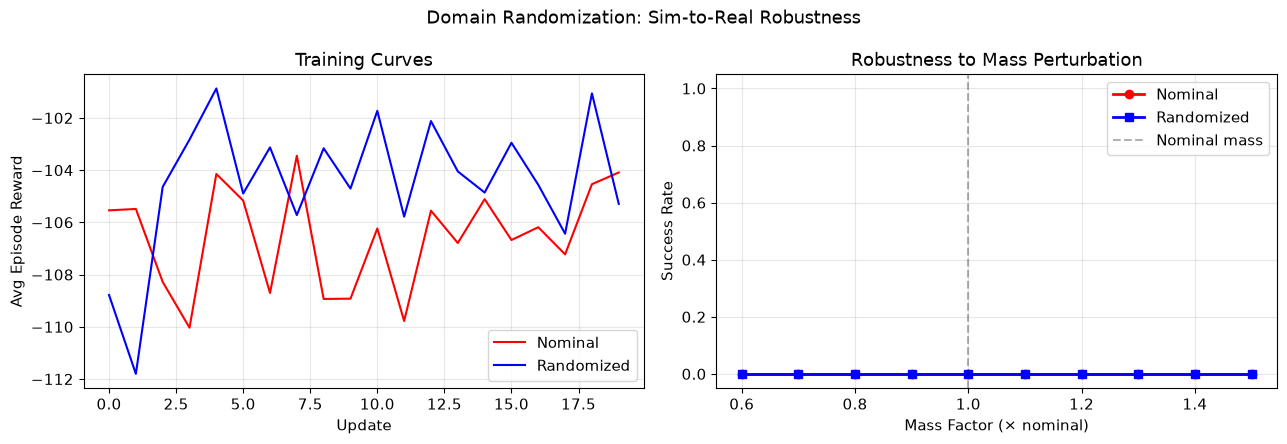

In [8]:
# --------------------------------------------------------------------------
# Domain randomization: robust policy training
# --------------------------------------------------------------------------


class RandomizedDroneEnv:
    """Wrapper that randomizes drone dynamics each episode."""

    base: DroneNavigationEnv
    rng: np.random.RandomState
    obs_dim: int
    act_dim: int
    nominal_mass: float
    nominal_kf: float
    _wind: np.ndarray

    def __init__(self, base_env: DroneNavigationEnv, seed: int = 42):
        self.base = base_env
        self.rng = np.random.RandomState(seed)
        self.obs_dim = base_env.obs_dim
        self.act_dim = base_env.act_dim
        self.nominal_mass = base_env.params.mass
        self.nominal_kf = base_env.params.k_f
        self._wind = np.zeros(3)

    def reset(self) -> np.ndarray:
        obs = self.base.reset()
        self.base.params.mass = self.nominal_mass * self.rng.uniform(0.7, 1.3)
        self.base.params.k_f = self.nominal_kf * self.rng.uniform(0.8, 1.2)
        self._wind = self.rng.randn(3) * 0.3
        return obs

    def step(self, action: np.ndarray):
        from src.drone import simulate_step

        thrusts = (action + 1) / 2 * self.base.params.max_thrust_per_motor
        self.base.state = simulate_step(
            self.base.state, thrusts, self.base.params, self.base.dt, wind=self._wind
        )
        self.base.step_count += 1
        obs = self.base._get_obs()
        reward = self.base._compute_reward(action)
        done = self.base._is_done()
        info = {
            "goal_reached": np.linalg.norm(self.base.state.position - self.base.goal)
            < 0.5
        }
        return obs, reward, done, info


def train_and_evaluate(
    env,
    label: str,
    n_updates: int = 20,
    steps_per_update: int = 300,
    seed: int = 42,
) -> tuple[PPO, list[float]]:
    """Train a PPO agent and return reward curve."""
    agent = PPO(
        obs_dim=env.obs_dim,
        act_dim=env.act_dim,
        lr_policy=1e-3,
        lr_value=3e-3,
        n_epochs=5,
        batch_size=64,
        seed=seed,
    )
    rewards = []

    for _update in range(n_updates):
        obs = env.reset()
        ep_rewards = []
        ep_r = 0
        for _step in range(steps_per_update):
            action, log_prob, value = agent.select_action(obs)
            action_c = np.clip(action, -1, 1)
            next_obs, reward, done, _ = env.step(action_c)
            agent.store_transition(obs, action_c, reward, done, log_prob, value)
            ep_r += reward
            obs = next_obs
            if done:
                ep_rewards.append(ep_r)
                ep_r = 0
                obs = env.reset()
        agent.update(obs)
        rewards.append(np.mean(ep_rewards) if ep_rewards else 0)

    return agent, rewards


def evaluate_on_perturbed(
    agent: PPO,
    base_env: DroneNavigationEnv,
    mass_factors: np.ndarray,
    n_trials: int = 10,
) -> list[float]:
    """Evaluate success rate across different mass perturbations."""
    nominal_mass = base_env.params.mass
    success_rates = []

    for mf in mass_factors:
        base_env.params.mass = nominal_mass * mf
        successes = 0
        for _ in range(n_trials):
            obs = base_env.reset()
            for _ in range(200):
                mean, _ = agent.policy.forward(obs.reshape(1, -1))
                action = np.clip(mean.flatten(), -1, 1)
                obs, _, done, info = base_env.step(action)
                if done:
                    if info.get("goal_reached", False):
                        successes += 1
                    break
        success_rates.append(successes / n_trials)

    base_env.params.mass = nominal_mass
    return success_rates


# Train nominal policy (no randomization)
nominal_env = DroneNavigationEnv(
    grid_shape=(30, 30, 10),
    resolution=0.3,
    n_obstacles=6,
    n_depth_rays=8,
    max_steps=200,
    dt=0.02,
    seed=200,
)
print("Training NOMINAL policy (no randomization)...")
nominal_agent, nominal_rewards = train_and_evaluate(
    nominal_env, "Nominal", n_updates=20, seed=42
)

# Train randomized policy
rand_env = RandomizedDroneEnv(
    DroneNavigationEnv(
        grid_shape=(30, 30, 10),
        resolution=0.3,
        n_obstacles=6,
        n_depth_rays=8,
        max_steps=200,
        dt=0.02,
        seed=200,
    ),
    seed=42,
)
print("Training RANDOMIZED policy (domain randomization)...")
rand_agent, rand_rewards = train_and_evaluate(
    rand_env, "Randomized", n_updates=20, seed=43
)

# Evaluate robustness
mass_factors = np.linspace(0.6, 1.5, 10)
test_env = DroneNavigationEnv(
    grid_shape=(30, 30, 10),
    resolution=0.3,
    n_obstacles=6,
    n_depth_rays=8,
    max_steps=200,
    dt=0.02,
    seed=200,
)

nominal_robustness = evaluate_on_perturbed(
    nominal_agent, test_env, mass_factors, n_trials=10
)
rand_robustness = evaluate_on_perturbed(rand_agent, test_env, mass_factors, n_trials=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(nominal_rewards, "r-", lw=1.5, label="Nominal")
ax.plot(rand_rewards, "b-", lw=1.5, label="Randomized")
ax.set_xlabel("Update")
ax.set_ylabel("Avg Episode Reward")
ax.set_title("Training Curves")
ax.legend()

ax = axes[1]
ax.plot(mass_factors, nominal_robustness, "r-o", lw=2, label="Nominal")
ax.plot(mass_factors, rand_robustness, "b-s", lw=2, label="Randomized")
ax.axvline(1.0, color="k", ls="--", alpha=0.3, label="Nominal mass")
ax.set_xlabel("Mass Factor (× nominal)")
ax.set_ylabel("Success Rate")
ax.set_title("Robustness to Mass Perturbation")
ax.legend()
ax.set_ylim(-0.05, 1.05)

plt.suptitle("Domain Randomization: Sim-to-Real Robustness", fontsize=13)
plt.tight_layout()
plt.show()


## 6. Speed and Agility: Racing and Aggressive Flight

### Champion-level drone racing (Kaufmann *et al.*, Nature 2023)

This landmark paper demonstrated that RL can train a drone to beat human
world champions in FPV drone racing — the first time an autonomous system
defeated human experts in a physical sport requiring real-time perception
and agile control.

### Architecture: privileged learning

The key innovation is a **three-phase training pipeline**:

**Phase 1 — RL teacher** (in simulation):
- Full access to privileged state: exact gate positions, drone velocity,
  relative pose to each gate, no sensor noise
- Trained with PPO across 100+ parallel simulation environments
- Optimizes for minimum lap time with collision penalties

**Phase 2 — Sensorimotor student** (in simulation):
- Only sees what onboard sensors provide: IMU + single front camera
- Learns to map raw sensor readings to motor commands
- Trained via DAgger-style supervised learning on teacher's actions
- The teacher's policy labels the student's rollouts, addressing covariate shift

**Phase 3 — Sim-to-real transfer**:
- System identification calibrates the simulator to the specific hardware
- Domain randomization for residual uncertainty (aerodynamic effects, latency)
- Deployed directly to hardware — no fine-tuning on real data

### Key findings

1. **Superhuman strategies**: The trained agent discovers aerodynamic
   maneuvers that human pilots don't use (e.g., exploiting ground effect,
   optimal banking through gates).

2. **Speed**: The autonomous system achieved faster lap times than human
   world champion pilots (average advantage of 0.5 seconds per lap).

3. **Failure mode**: The main limitation is perception — the system
   occasionally misjudges gate positions in challenging lighting, while
   human pilots use contextual reasoning to handle ambiguity.

### Gate-passing reward formulation

For a sequence of gates \(\{g_1, g_2, \ldots, g_K\}\):

$$r = -\Delta t + \sum_{k} \left[ r_{\text{pass}}(g_k) - c_{\text{miss}} \cdot \mathbb{1}[\text{miss } g_k] \right]$$

where \(\Delta t\) is the time penalty (encourages speed) and
\(r_{\text{pass}}(g_k)\) is a bonus for passing through gate \(k\).

### ViT for high-speed obstacle avoidance (2024–2026)

Beyond racing, recent work extends end-to-end control to **obstacle
avoidance at high speed** in unknown environments:

- **ViT+LSTM** (2024): Vision transformer processes depth images at 30 Hz,
  LSTM maintains temporal context. Tested up to 7 m/s, outperforms CNN
  baselines at high speeds and in unseen environments. Key: attention
  enables global context, critical when obstacles are far apart.

- **Event-depth fusion** (2026): For speeds approaching 17 m/s, standard
  depth cameras suffer from motion blur. **Event cameras** capture
  asynchronous per-pixel brightness changes with microsecond resolution.
  A bidirectional cross-attention module fuses depth (good for static
  obstacles) with events (good for dynamic obstacles), achieving 70–80%
  success rate at 17 m/s — nearly 2× faster than previous methods.

### Time-optimized safe navigation (2025)

A complete onboard system for navigation in unknown environments:
1. **Dense depth** from stereo + monocular learning-based depth fusion
   (longer range, less noise than pure stereo)
2. **Time-optimal trajectory generation** within safe corridors carved
   from the incrementally built 3D map
3. **Continuous replanning** as new depth measurements update the map

This represents the state of the art for modular navigation: each
component is independently verifiable and the system provides formal
safety guarantees through the safe-corridor formulation.

Training racing policy...


  Update 10: reward=1.2, gates=0.0/5


  Update 20: reward=2.0, gates=0.0/5


  Update 30: reward=0.4, gates=0.0/5


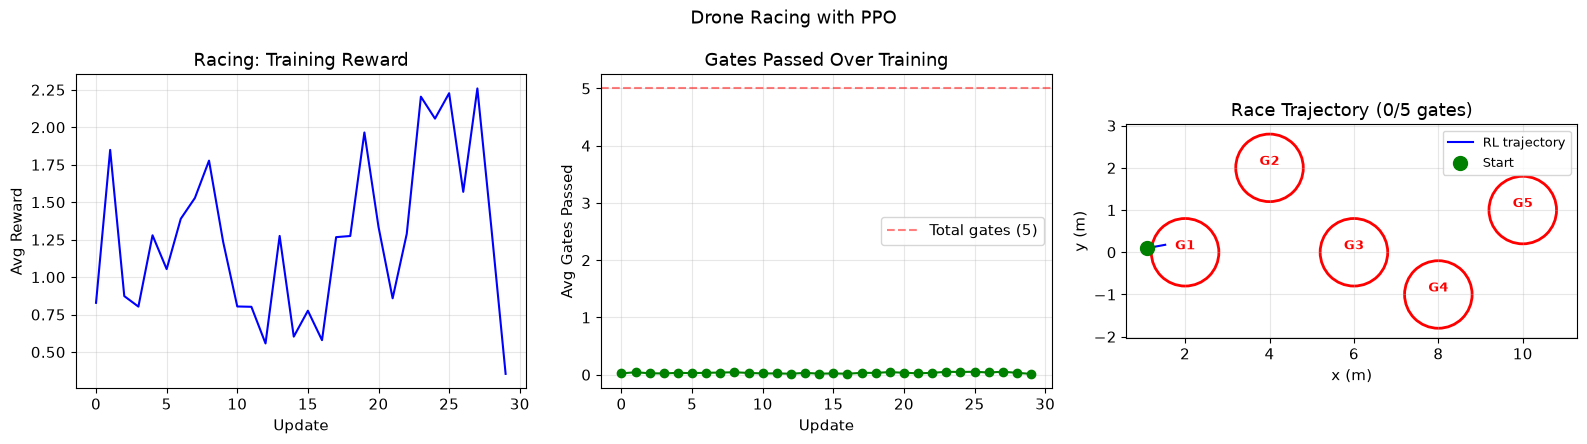

In [9]:
from matplotlib.patches import Circle

# --------------------------------------------------------------------------
# Simple gate-passing / racing environment
# --------------------------------------------------------------------------


class GateRacingEnv:
    """Simplified drone racing: fly through waypoint gates as fast as possible."""

    gates: np.ndarray
    gate_radius: float
    max_steps: int
    dt: float
    params: QuadrotorParams
    rng: np.random.RandomState
    obs_dim: int
    act_dim: int
    state: QuadrotorState
    current_gate: int
    step_count: int

    def __init__(
        self,
        gates: np.ndarray,
        gate_radius: float = 0.8,
        max_steps: int = 500,
        dt: float = 0.02,
        seed: int = 42,
    ):
        self.gates = gates
        self.gate_radius = gate_radius
        self.max_steps = max_steps
        self.dt = dt
        self.params = QuadrotorParams()
        self.rng = np.random.RandomState(seed)

        self.obs_dim = 12 + 3  # state + relative gate position
        self.act_dim = 4
        # The environment always has a drone state; ``reset`` establishes the
        # episode's initial pose, so construct one here rather than leaving the
        # attribute unset until the first reset.
        self.state = QuadrotorState()
        self.current_gate = 0
        self.step_count = 0
        self.reset()

    def reset(self) -> np.ndarray:
        self.state = QuadrotorState()
        self.state.position = self.gates[0] - np.array([1.0, 0.0, 0.0])
        self.state.position += self.rng.randn(3) * 0.1
        self.current_gate = 0
        self.step_count = 0
        return self._get_obs()

    def step(self, action: np.ndarray):
        thrusts = (action + 1) / 2 * self.params.max_thrust_per_motor
        self.state = simulate_step(self.state, thrusts, self.params, self.dt)
        self.step_count += 1

        obs = self._get_obs()
        reward, gate_passed = self._compute_reward(action)
        done = self._is_done()

        return (
            obs,
            reward,
            done,
            {
                "gates_passed": self.current_gate,
                "gate_just_passed": gate_passed,
                "all_gates": self.current_gate >= len(self.gates),
            },
        )

    def _get_obs(self) -> np.ndarray:
        if self.current_gate < len(self.gates):
            gate_rel = self.gates[self.current_gate] - self.state.position
        else:
            gate_rel = np.zeros(3)

        euler = self.state.euler_angles
        return np.concatenate(
            [
                gate_rel,
                self.state.velocity,
                euler,
                self.state.omega,
                gate_rel,  # duplicate for emphasis
            ]
        )

    def _compute_reward(self, action: np.ndarray) -> tuple[float, bool]:
        reward = -0.01  # time penalty
        gate_passed = False

        if self.current_gate < len(self.gates):
            dist = np.linalg.norm(self.state.position - self.gates[self.current_gate])
            reward += -0.1 * dist  # progress reward

            if dist < self.gate_radius:
                reward += 50.0
                gate_passed = True
                self.current_gate += 1

        if self.current_gate >= len(self.gates):
            reward += 100.0  # completed course

        reward -= 0.001 * np.sum(action**2)

        return float(reward), gate_passed

    def _is_done(self) -> bool:
        if self.step_count >= self.max_steps:
            return True
        if self.current_gate >= len(self.gates):
            return True
        if self.state.position[2] < -1.0 or self.state.position[2] > 5.0:
            return True
        tilt = np.arccos(np.clip(self.state.rotation[2, 2], -1, 1))
        return bool(tilt > np.radians(80))


# Define a race course
race_gates = np.array(
    [
        [2.0, 0.0, 1.5],
        [4.0, 2.0, 1.5],
        [6.0, 0.0, 2.0],
        [8.0, -1.0, 1.5],
        [10.0, 1.0, 1.5],
    ]
)

race_env = GateRacingEnv(race_gates, gate_radius=0.8, max_steps=500, dt=0.02, seed=42)

race_ppo = PPO(
    obs_dim=race_env.obs_dim,
    act_dim=race_env.act_dim,
    lr_policy=1e-3,
    lr_value=3e-3,
    n_epochs=5,
    batch_size=64,
    seed=42,
)

n_race_updates = 30
race_rewards = []
race_gates_passed = []

print("Training racing policy...")
for update in range(n_race_updates):
    obs = race_env.reset()
    ep_rewards, ep_gates = [], []
    ep_r = 0

    for _step in range(600):
        action, log_prob, value = race_ppo.select_action(obs)
        action_c = np.clip(action, -1, 1)
        next_obs, reward, done, info = race_env.step(action_c)
        race_ppo.store_transition(obs, action_c, reward, done, log_prob, value)
        ep_r += reward
        obs = next_obs

        if done:
            ep_rewards.append(ep_r)
            ep_gates.append(info["gates_passed"])
            ep_r = 0
            obs = race_env.reset()

    race_ppo.update(obs)
    race_rewards.append(np.mean(ep_rewards) if ep_rewards else 0)
    race_gates_passed.append(np.mean(ep_gates) if ep_gates else 0)

    if (update + 1) % 10 == 0:
        print(
            f"  Update {update + 1}: reward={race_rewards[-1]:.1f}, "
            f"gates={race_gates_passed[-1]:.1f}/{len(race_gates)}"
        )

# Evaluate & visualize
obs = race_env.reset()
race_traj = [race_env.state.position.copy()]
# Seed from the environment's own bookkeeping so the gate count is defined even
# if the episode terminates on the very first step.
race_info: dict[str, object] = {"gates_passed": race_env.current_gate}
for _ in range(500):
    mean, _ = race_ppo.policy.forward(obs.reshape(1, -1))
    action = np.clip(mean.flatten(), -1, 1)
    obs, _, done, info = race_env.step(action)
    race_info = info
    race_traj.append(race_env.state.position.copy())
    if done:
        break
race_traj = np.array(race_traj)
_gates_raw = race_info.get("gates_passed", race_env.current_gate)
gates_passed_final = _gates_raw if isinstance(_gates_raw, int) else race_env.current_gate

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(race_rewards, "b-", lw=1.5)
ax.set_xlabel("Update")
ax.set_ylabel("Avg Reward")
ax.set_title("Racing: Training Reward")

ax = axes[1]
ax.plot(race_gates_passed, "g-o", lw=1.5)
ax.axhline(
    len(race_gates),
    color="r",
    ls="--",
    alpha=0.5,
    label=f"Total gates ({len(race_gates)})",
)
ax.set_xlabel("Update")
ax.set_ylabel("Avg Gates Passed")
ax.set_title("Gates Passed Over Training")
ax.legend()

ax = axes[2]
ax.plot(race_traj[:, 0], race_traj[:, 1], "b-", lw=1.5, label="RL trajectory")
for i, g in enumerate(race_gates):
    circle = Circle(g[:2], 0.8, fill=False, color="red", lw=2)
    ax.add_patch(circle)
    ax.annotate(
        f"G{i + 1}",
        g[:2],
        fontsize=9,
        ha="center",
        va="bottom",
        color="red",
        fontweight="bold",
    )
ax.plot(race_traj[0, 0], race_traj[0, 1], "go", ms=10, label="Start")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Race Trajectory ({gates_passed_final}/{len(race_gates)} gates)")
ax.legend(fontsize=9)
ax.set_aspect("equal")

plt.suptitle("Drone Racing with PPO", fontsize=13)
plt.tight_layout()
plt.show()


## 7. Visual Odometry Integration

In practice, a drone doesn't have access to a pre-built map.
It must estimate its own motion (**visual odometry**, NB07) and
build the map incrementally.

### Incremental mapping pipeline

At each timestep \(t\):
1. **Capture** a depth scan from the current pose \(T_t \in SE(3)\).
2. **Estimate ego-motion** \(\Delta T_{t \to t+1}\) from consecutive observations
   via visual odometry or VIO (NB07, NB20).
3. **Transform** depth readings to world frame: \(\mathbf{p}_w = T_t \cdot K^{-1} \tilde{\mathbf{u}} \cdot Z(u,v)\).
4. **Integrate** the points into a growing occupancy grid via log-odds update:
   $$L(m_i) \leftarrow L(m_i) + l_{\text{meas}}(m_i) - l_{\text{prior}}$$
   where \(l_{\text{meas}} = \log\frac{p(\text{occ} | z)}{1 - p(\text{occ} | z)}\).
5. **Replan** on the updated map when new obstacles are discovered.

### The chicken-and-egg problem

SLAM faces a fundamental circularity:
- **Good localization** requires a good map (to match features against)
- **Good mapping** requires good localization (to place observations correctly)

Modern SLAM resolves this via **joint optimization**: the map and pose estimates
are refined simultaneously, typically in a factor graph (NB14). For real-time
drone navigation, we use the EKF from NB20 for localization and incrementally
build the map, accepting some map noise in exchange for low latency.

### Pose uncertainty propagation

The occupancy grid doesn't account for **localization uncertainty**. If the
drone's position estimate has covariance \(\Sigma_p\), each depth reading is
placed with uncertainty:

$$\Sigma_{\mathbf{p}_w} = J_T \Sigma_p J_T^\top + J_Z \sigma_Z^2 J_Z^\top$$

where \(J_T\) is the Jacobian w.r.t. pose and \(J_Z\) w.r.t. depth.
High uncertainty should inflate the obstacle region — a principled way to
increase safety margins when localization degrades.

### Zero-shot metric depth for navigation (2025)

A recent approach by the RISLAB group (2025) eliminates the need for
stereo cameras or LiDAR entirely: a monocular camera + IMU estimates
metric depth via **monotonic spline rescaling** of relative depth predictions:

1. Run a foundation depth model (Depth Anything V2) → relative depth \(\hat{d}\)
2. Run VIO (NB20) → sparse 3D feature map with metric scale
3. Fit a monotonic spline: \(d_{\text{metric}} = f_{\text{spline}}(\hat{d})\) using
   sparse VIO points as anchors
4. Integrate metric depth into occupancy grid at **15 Hz** on a
   compute-constrained quadrotor

This achieves collision avoidance in real-world flight with a single
\(\sim\)20 g camera — no stereo rig or LiDAR needed.

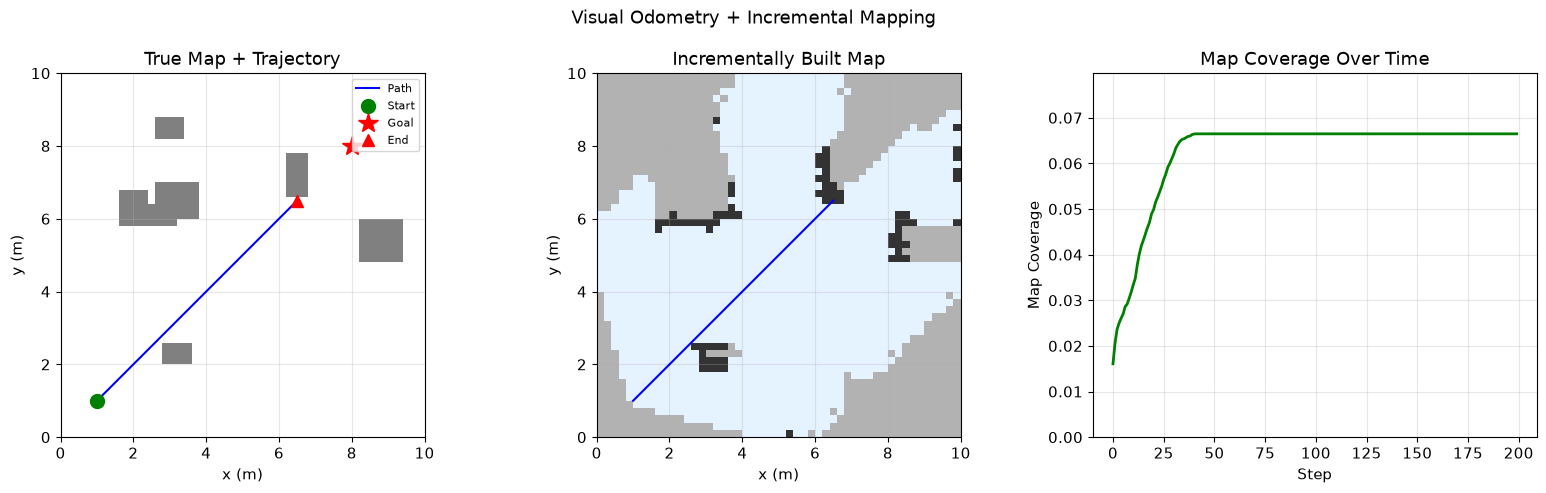

Goal reached: False
Final coverage: 6.65%
Path length: 7.79 m


In [10]:
# --------------------------------------------------------------------------
# Visual odometry + incremental mapping
# --------------------------------------------------------------------------


class IncrementalMapper:
    """Builds an occupancy grid incrementally from depth scans."""

    grid: OccupancyGrid3D
    known: np.ndarray
    resolution: float

    def __init__(self, grid_shape=(60, 60, 10), resolution=0.2, origin=np.zeros(3)):
        self.grid = OccupancyGrid3D(
            np.zeros(grid_shape, dtype=bool), resolution, origin.copy()
        )
        self.known = np.zeros(grid_shape, dtype=bool)  # True if observed
        self.resolution = resolution

    def integrate_scan(
        self,
        position: np.ndarray,
        depths: np.ndarray,
        angles: np.ndarray,
    ):
        """Add depth readings to the map."""
        for depth_val, angle in zip(depths, angles, strict=False):
            direction = np.array([np.cos(angle), np.sin(angle), 0.0])
            # Mark free space along the ray
            for d in np.arange(self.resolution, min(depth_val, 4.9), self.resolution):
                point = position + d * direction
                idx = self.grid.world_to_grid(point)
                if self.grid.is_valid(idx):
                    self.known[idx] = True

            # Mark obstacle at the endpoint
            if depth_val < 4.9:
                hit = position + depth_val * direction
                idx = self.grid.world_to_grid(hit)
                if self.grid.is_valid(idx):
                    self.grid.grid[idx] = True
                    self.known[idx] = True

    @property
    def coverage(self) -> float:
        """Fraction of grid cells that have been observed."""
        return np.sum(self.known) / self.known.size


def simulate_vo_navigation(
    true_grid: OccupancyGrid3D,
    start: np.ndarray,
    goal: np.ndarray,
    vo_noise_std: float = 0.02,
    n_steps: int = 100,
) -> tuple[IncrementalMapper, np.ndarray, list[float]]:
    """Simulate navigation with incremental VO-based mapping."""
    mapper = IncrementalMapper(
        grid_shape=true_grid.shape,
        resolution=true_grid.resolution,
        origin=true_grid.origin,
    )

    pos = start.copy()
    estimated_pos = start.copy()  # VO estimate (with drift)
    positions = [pos.copy()]
    coverages = []

    for _step in range(n_steps):
        # "See" the environment from current position
        yaw = np.arctan2(goal[1] - pos[1], goal[0] - pos[0])
        depths, angles = synthesize_depth_from_grid(
            true_grid, pos, yaw, n_rays=24, fov=np.radians(120)
        )

        # VO estimates position with noise
        estimated_pos = pos + np.random.randn(3) * vo_noise_std

        # Integrate into map using estimated pose
        mapper.integrate_scan(estimated_pos, depths, angles)
        coverages.append(mapper.coverage)

        # Try to plan on the incremental map
        planned = astar_3d(mapper.grid, pos, goal)

        if planned is not None and len(planned) > 1:
            direction = planned[1] - pos
        else:
            direction = goal - pos

        dist = np.linalg.norm(direction)
        if dist > 0.01:
            direction = direction / dist
        else:
            break

        step_size = min(0.2, dist)
        new_pos = pos + step_size * direction

        if true_grid.is_free_world(new_pos):
            pos = new_pos
        positions.append(pos.copy())

        if np.linalg.norm(pos - goal) < 0.5:
            break

    return mapper, np.array(positions), coverages


# Run incremental VO navigation
vo_grid = create_random_obstacles(
    grid_shape=(50, 50, 10),
    n_obstacles=10,
    obstacle_size_range=(3, 6),
    resolution=0.2,
    origin=np.zeros(3),
    seed=55,
)

vo_start = np.array([1.0, 1.0, 1.0])
vo_goal = np.array([8.0, 8.0, 1.0])

mapper, vo_positions, coverages = simulate_vo_navigation(
    vo_grid, vo_start, vo_goal, vo_noise_std=0.02, n_steps=200
)

# Visualize map growth
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# True map
ax = axes[0]
occ_true = vo_grid.grid[:, :, 5].T
ext_vo = [
    vo_grid.origin[0],
    vo_grid.origin[0] + vo_grid.shape[0] * vo_grid.resolution,
    vo_grid.origin[1],
    vo_grid.origin[1] + vo_grid.shape[1] * vo_grid.resolution,
]
ax.imshow(occ_true, origin="lower", extent=ext_vo, cmap="Greys", alpha=0.5)
ax.plot(vo_positions[:, 0], vo_positions[:, 1], "b-", lw=1.5, label="Path")
ax.plot(*vo_start[:2], "go", ms=10, label="Start")
ax.plot(*vo_goal[:2], "r*", ms=15, label="Goal")
ax.plot(vo_positions[-1, 0], vo_positions[-1, 1], "r^", ms=8, label="End")
ax.set_title("True Map + Trajectory")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.legend(fontsize=8)

# Built map
ax = axes[1]
built_map = mapper.grid.grid[:, :, 5].T.astype(float)
known_map = mapper.known[:, :, 5].T.astype(float)
rgb_map = np.zeros((*built_map.shape, 3))
rgb_map[known_map > 0, :] = [0.9, 0.95, 1.0]  # known-free: light blue
rgb_map[built_map > 0, :] = [0.2, 0.2, 0.2]  # obstacles: dark
rgb_map[known_map == 0, :] = [0.7, 0.7, 0.7]  # unknown: grey
ax.imshow(rgb_map, origin="lower", extent=ext_vo)
ax.plot(vo_positions[:, 0], vo_positions[:, 1], "b-", lw=1.5)
ax.set_title("Incrementally Built Map")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

# Coverage over time
ax = axes[2]
ax.plot(coverages, "g-", lw=2)
ax.set_xlabel("Step")
ax.set_ylabel("Map Coverage")
ax.set_title("Map Coverage Over Time")
ax.set_ylim(0, max(coverages) * 1.2)

plt.suptitle("Visual Odometry + Incremental Mapping", fontsize=13)
plt.tight_layout()
plt.show()

reached = np.linalg.norm(vo_positions[-1] - vo_goal) < 0.5
print(f"Goal reached: {reached}")
print(f"Final coverage: {coverages[-1]:.2%}")
print(f"Path length: {path_length(vo_positions):.2f} m")


## 8. Active Exploration

The previous section navigated toward a known goal. But what if the
goal is to **explore** the environment — "Where should I fly to build
the best map?"

### Frontier-based exploration (Yamauchi, 1997)

A **frontier** is the boundary between known-free space and unknown space.
The algorithm:

1. **Find frontiers**: voxels that are known-free and adjacent to unknown space.
2. **Evaluate each frontier** by information gain — how many unknown voxels
   are nearby:
   $$\text{utility}(f) = \frac{\text{unknown voxels near } f}{\text{path cost to } f}$$
3. **Navigate** to the frontier with highest utility.
4. **Repeat** until coverage exceeds a threshold.

### Information-theoretic optimal exploration

Frontier-based exploration is a greedy approximation to the optimal
exploration problem. The true objective maximizes the
**information gain** (mutual information between the map and observations):

$$\pi^* = \arg\max_\pi \; \mathbb{E}\!\left[\sum_t I(M; z_t \mid z_{1:t-1})\right]
= \arg\max_\pi \; \mathbb{E}\!\left[\sum_t \bigl(H[M_t \mid z_{1:t-1}] - H[M_t \mid z_{1:t}]\bigr)\right]$$

where \(M_t\) is the map at time \(t\), \(z_t\) is the observation, and
\(I(\cdot;\cdot)\) is the mutual information. Maximizing the
difference means choosing actions that reduce uncertainty the most.

**Why this is hard**: computing the expected information gain requires
reasoning about which voxels the sensor *would see* from each candidate
viewpoint — a **next-best-view** problem that is NP-hard in general.
Approximations include:
- **Ray-casting**: simulate sensor beams from each candidate pose, count
  unknown voxels that would be observed → \(O(N_{\text{rays}} \cdot N_{\text{poses}})\)
- **Volumetric information**: assume each unknown voxel contributes
  entropy \(H_{\text{binary}} = -p \log p - (1-p) \log(1-p)\) where \(p\)
  is the current occupancy probability
- **Submodularity**: the information gain function is submodular (diminishing
  returns), so the greedy algorithm achieves a \((1 - 1/e)\) approximation
  to the optimal multi-step plan (Krause & Guestrin, 2005)

### Coverage path planning

For inspection and survey missions, the goal is not just exploration but
**complete coverage**: every surface voxel must be observed from a close
viewpoint. This is a variant of the **art gallery problem** / **watchman
route problem**, and is solved via:
- **Boustrophedon (lawnmower)**: systematic sweeps at fixed altitude
- **Sampling-based**: sample viewpoints that cover the surface, then solve
  a traveling salesman problem (TSP) to visit them efficiently
- **Adaptive**: prioritize regions with high uncertainty or features of
  interest (cracks, defects)

### Learning-based exploration

Recent work replaces hand-crafted utility functions with learned policies:
- **MAGICIAN** (CVPR 2026): learns exploration policies from partial maps,
  predicting which directions yield the most new information
- **GBPlanner3** (Unified Autonomy Stack, 2025): sampling-based exploration
  in a volumetric map, tested in subterranean environments where frontiers
  may be misleading (narrow passages, multi-level structures)

### Foundation Models for Visual Navigation (2025–2026)

The rapid progress in **visual foundation models** — large-scale
pretrained networks for depth, matching, and 3D reconstruction — is
reshaping the classical perceive-map-plan-act pipeline. Instead of
hand-crafted feature extractors and stereo matching algorithms, modern
systems can drop in foundation models that generalize across scenes
with zero or minimal fine-tuning.

#### VGGT and Dense Reconstruction (2025–2026)

**VGGT** (Visual Geometry Grounded Transformer; Wang *et al.*, CVPR 2025)
demonstrated that a single feed-forward Transformer can predict camera
poses, depth maps, point maps, and 3D point tracks from unposed images
— all in a single pass, without iterative optimization or RANSAC.

By 2026, extensions like **VGGT-SLAM 2.0** push this further:
- **Feed-forward dense reconstruction**: given a sequence of frames,
  produce a globally consistent 3D point cloud without bundle adjustment
- **Real-time operation**: the Transformer processes frames at ~15 Hz on
  a mobile GPU, competitive with classical stereo pipelines
- **Generalization**: trained on internet-scale data, it handles textureless
  surfaces, reflective materials, and dynamic objects that trip up
  traditional feature-based methods

This transforms SLAM from an *optimization problem* (minimize reprojection
error over a factor graph) into a *prediction problem* (directly regress
3D structure), dramatically reducing engineering complexity.

#### MASt3R-Fusion: Visual Foundations Meet Classical Sensors (2025)

**MASt3R** (Matching And Stereo 3D Reconstruction; Leroy *et al.*, 2025)
is a foundation model for dense stereo matching. **MASt3R-Fusion**
integrates it with classical IMU and GNSS sensors:

$$\hat{\mathbf{X}} = f_{\text{MASt3R}}(I_1, I_2) \quad \oplus \quad \text{IMU preintegration} \quad \oplus \quad \text{GNSS fixes}$$

Key insight: the foundation model provides **dense** metric 3D from
image pairs (filling the gaps between sparse GNSS fixes and drift-prone
IMU integration), while classical sensors provide the **absolute scale**
and **global reference frame** that purely visual methods struggle with.

Result: centimeter-level mapping accuracy outdoors, 5× denser than
LiDAR-only approaches, at a fraction of the sensor cost.

#### VIDAR: Coupling VIO with Learned Depth (2026)

**VIDAR** (Visual-Inertial Dense Accurate Reconstruction; 2026) takes a
complementary approach — instead of replacing VIO with a foundation model,
it **augments** a classical VIO pipeline with dense depth predictions from
**Depth Anything 3**:

1. Run standard VIO (NB20) → sparse features + accurate metric poses
2. Run Depth Anything 3 → dense relative depth at each keyframe
3. **Rescale** the dense depth using sparse VIO points as metric anchors
   (via the monotonic spline technique from RISLAB, 2025)
4. Fuse rescaled dense depth into a **TSDF** (truncated signed distance
   field) for volumetric reconstruction

$$d_{\text{metric}}(u,v) = f_{\text{spline}}\!\left(\hat{d}_{\text{DA3}}(u,v);\; \{(d^{\text{VIO}}_k, \hat{d}^{\text{DA3}}_k)\}_{k=1}^{K}\right)$$

The result is a system that inherits the **metric accuracy** of VIO and
the **visual completeness** of foundation depth models — producing dense
reconstructions at 15 Hz on embedded compute.

#### How Foundation Models Transform the Navigation Pipeline

The classical pipeline:
```
Camera → Feature extraction → Stereo matching → Sparse map → Path planning → Control
                ↑ hand-crafted        ↑ fragile
```

The foundation-model pipeline:
```
Camera → Foundation depth/3D → Dense metric map → Path planning → Control
              ↑ pretrained           ↑ robust
```

Key advantages:
- **No per-scene calibration**: foundation models generalize across environments
- **Dense reconstruction**: every pixel contributes to the map, not just
  corners/edges → better obstacle detection, especially for thin structures
- **Robustness**: trained on millions of images, these models handle degraded
  conditions (rain, fog, low light) far better than hand-crafted pipelines

#### The "Middle Ground" Problem

Despite this progress, a practical gap remains: **no permissively-licensed,
foundation-3D-aware Python VIO library exists yet** (as of mid-2026).

- ORB-SLAM3, VINS-Mono, OpenVINS: classical C++ codebases, GPL-licensed,
  difficult to integrate with Python-based foundation models
- DPVO, DROID-SLAM: learned visual odometry in Python/PyTorch, but
  research-quality code without production-grade IMU fusion
- VGGT, MASt3R: impressive 3D from images, but no real-time incremental
  SLAM loop with IMU integration

This "middle ground" — a clean, permissively-licensed Python library
that fuses foundation depth/3D models with IMU for real-time metric
VIO — is an active area of development and an opportunity for the
open-source community. Until it exists, practical systems must either
wrap C++ VIO libraries or sacrifice real-time performance for
Python-native solutions.

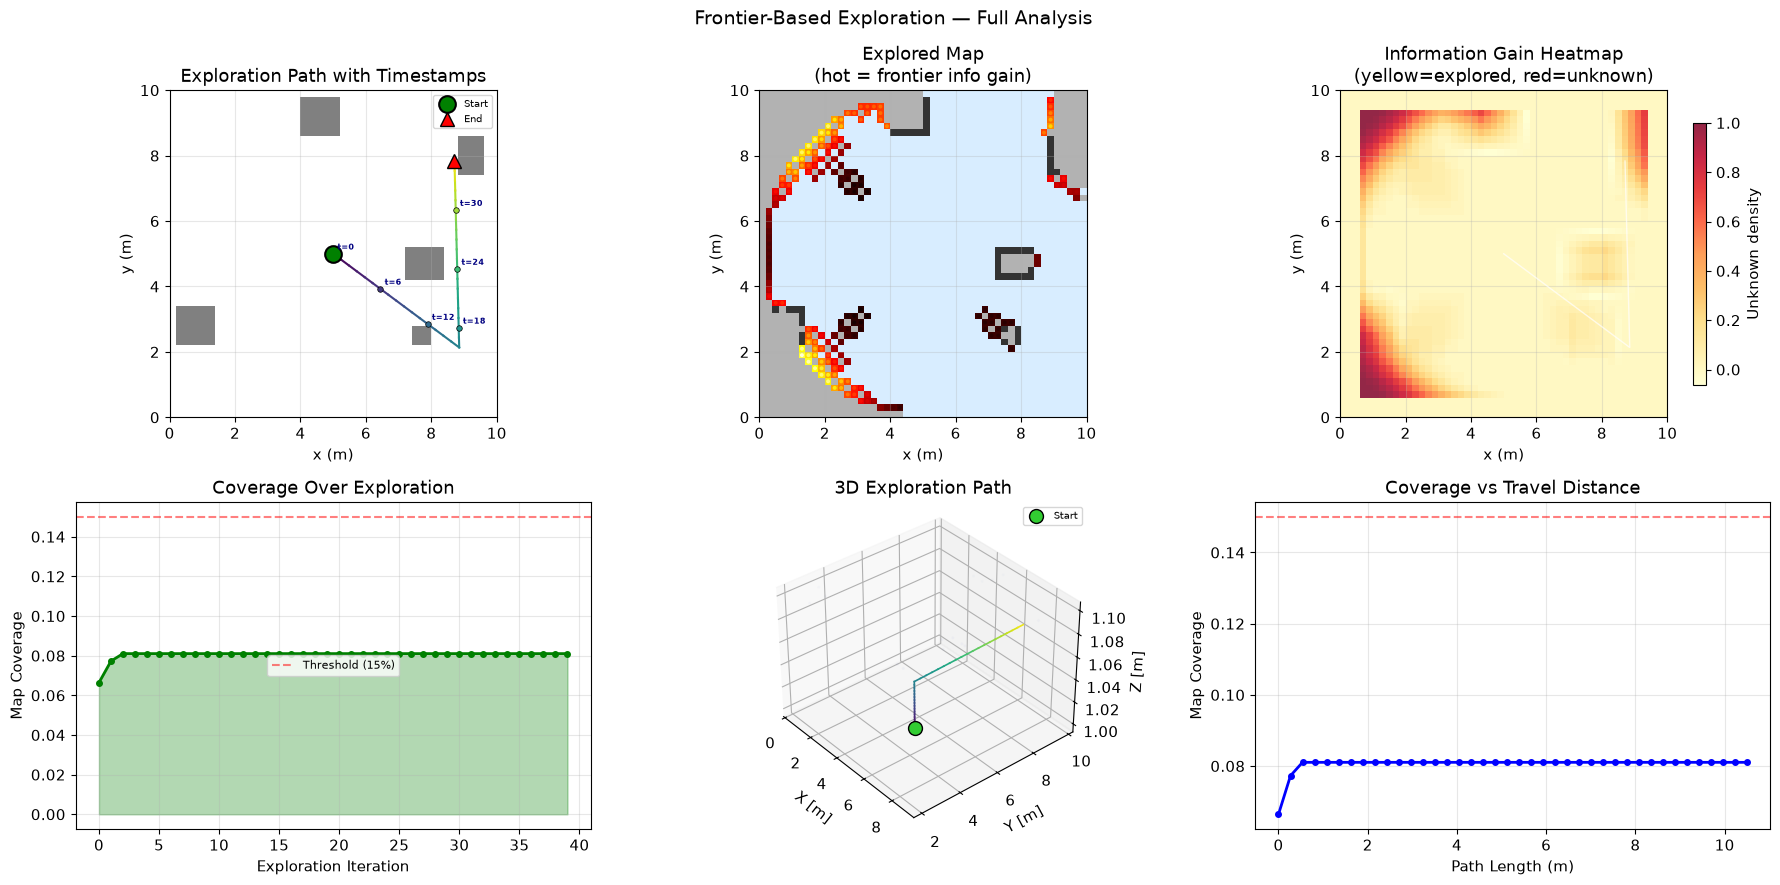

Final coverage: 8.10%
Exploration steps: 36
Path length: 10.50 m


In [11]:
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------------------------------------
# Frontier-based exploration
# --------------------------------------------------------------------------


def find_frontiers(
    known: np.ndarray,
    occupied: np.ndarray,
    grid: OccupancyGrid3D,
    z_slice: int = 5,
) -> np.ndarray:
    """Find frontier voxels (known-free adjacent to unknown) on a z-slice.

    Returns a ``(N, 3)`` float array of world-frame frontier centres.
    """
    hits: list[tuple[int, int, int]] = []
    nx, ny, _nz = known.shape

    for x in range(1, nx - 1):
        for y in range(1, ny - 1):
            z = z_slice
            if not known[x, y, z] or occupied[x, y, z]:
                continue
            # Check if adjacent to unknown
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nx_, ny_ = x + dx, y + dy
                if 0 <= nx_ < nx and 0 <= ny_ < ny and not known[nx_, ny_, z]:
                    hits.append((x, y, z))
                    break

    if not hits:
        return np.zeros((0, 3), dtype=float)
    return np.array([grid.grid_to_world(h) for h in hits], dtype=float)


def count_unknown_nearby(
    position: np.ndarray,
    known: np.ndarray,
    grid: OccupancyGrid3D,
    radius: int = 5,
) -> int:
    """Count unknown voxels near a position."""
    center = grid.world_to_grid(position)
    count = 0
    nx, ny, nz = known.shape
    for dx in range(-radius, radius + 1):
        for dy in range(-radius, radius + 1):
            x, y = center[0] + dx, center[1] + dy
            z = center[2]
            if 0 <= x < nx and 0 <= y < ny and 0 <= z < nz and not known[x, y, z]:
                count += 1
    return count


def frontier_exploration(
    true_grid: OccupancyGrid3D,
    start: np.ndarray,
    max_iterations: int = 40,
    coverage_threshold: float = 0.15,
    n_rays: int = 24,
) -> tuple[np.ndarray, list[float], IncrementalMapper]:
    """Run frontier-based exploration."""
    mapper = IncrementalMapper(
        grid_shape=true_grid.shape,
        resolution=true_grid.resolution,
        origin=true_grid.origin,
    )

    pos = start.copy()
    positions = [pos.copy()]
    coverages = []

    for _it in range(max_iterations):
        # Scan
        for yaw in np.linspace(0, 2 * np.pi, 8, endpoint=False):
            depths, angles = synthesize_depth_from_grid(
                true_grid, pos, yaw, n_rays=n_rays, fov=np.radians(60)
            )
            mapper.integrate_scan(pos, depths, angles)

        coverages.append(mapper.coverage)
        if mapper.coverage >= coverage_threshold:
            break

        # Find frontiers
        z_idx = mapper.grid.world_to_grid(pos)[2]
        frontiers = find_frontiers(
            mapper.known, mapper.grid.grid, mapper.grid, z_slice=z_idx
        )

        if frontiers.shape[0] == 0:
            break

        # Evaluate frontiers: utility = unknown_count / path_cost
        best_frontier = None
        best_utility = -1

        for f in frontiers:
            unknown_count = count_unknown_nearby(f, mapper.known, mapper.grid, radius=5)
            dist = np.linalg.norm(f - pos)
            if dist < 0.3:
                continue
            utility = unknown_count / (dist + 0.1)
            if utility > best_utility:
                best_utility = utility
                best_frontier = f

        if best_frontier is None:
            break

        # Navigate to frontier (simple direct motion)
        direction = best_frontier - pos
        dist = np.linalg.norm(direction)
        if dist > 0.01:
            n_move_steps = max(1, int(dist / 0.3))
            for _ in range(n_move_steps):
                step_dir = best_frontier - pos
                sd = np.linalg.norm(step_dir)
                if sd < 0.3:
                    break
                new_pos = pos + 0.3 * step_dir / sd
                if true_grid.is_free_world(new_pos):
                    pos = new_pos
                    positions.append(pos.copy())
                else:
                    break

    return np.array(positions), coverages, mapper


# Run exploration
explore_grid = create_random_obstacles(
    grid_shape=(50, 50, 10),
    n_obstacles=10,
    obstacle_size_range=(3, 6),
    resolution=0.2,
    origin=np.zeros(3),
    seed=77,
)

explore_start = np.array([5.0, 5.0, 1.0])
explore_positions, explore_coverages, explore_mapper = frontier_exploration(
    explore_grid, explore_start, max_iterations=40, coverage_threshold=0.15
)

# Visualize exploration with enhanced information gain and frontier displays
fig = plt.figure(figsize=(18, 9))

ext_e = (
    explore_grid.origin[0],
    explore_grid.origin[0] + explore_grid.shape[0] * explore_grid.resolution,
    explore_grid.origin[1],
    explore_grid.origin[1] + explore_grid.shape[1] * explore_grid.resolution,
)

# --- (1) Exploration trajectory with timestamps ---
ax1 = fig.add_subplot(231)
true_occ_e = explore_grid.grid[:, :, 5].T
ax1.imshow(true_occ_e, origin="lower", extent=ext_e, cmap="Greys", alpha=0.5)
_n_exp = len(explore_positions)
_time_colors = plt.cm.viridis(np.linspace(0, 1, _n_exp))
for _i in range(_n_exp - 1):
    ax1.plot(
        explore_positions[_i : _i + 2, 0],
        explore_positions[_i : _i + 2, 1],
        "-",
        color=_time_colors[_i],
        lw=1.5,
    )
# Timestamp annotations along path
_ts_step = max(1, _n_exp // 6)
for _i in range(0, _n_exp, _ts_step):
    ax1.annotate(
        f"t={_i}",
        (explore_positions[_i, 0], explore_positions[_i, 1]),
        fontsize=6,
        color="navy",
        fontweight="bold",
        xytext=(3, 3),
        textcoords="offset points",
    )
    ax1.plot(
        explore_positions[_i, 0],
        explore_positions[_i, 1],
        "o",
        color=_time_colors[_i],
        ms=4,
        markeredgecolor="k",
        markeredgewidth=0.5,
    )
ax1.plot(
    *explore_start[:2],
    "go",
    ms=12,
    label="Start",
    markeredgecolor="k",
    markeredgewidth=1.5,
)
ax1.plot(
    explore_positions[-1, 0],
    explore_positions[-1, 1],
    "r^",
    ms=10,
    label="End",
    markeredgecolor="k",
    markeredgewidth=1.0,
)
ax1.set_title("Exploration Path with Timestamps")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")
ax1.legend(fontsize=7)

# --- (2) Explored map with frontier coloring ---
ax2 = fig.add_subplot(232)
built_e = explore_mapper.grid.grid[:, :, 5].T.astype(float)
known_e = explore_mapper.known[:, :, 5].T.astype(float)
_n_e0, _n_e1 = built_e.shape[0], built_e.shape[1]
display_e = np.zeros((_n_e0, _n_e1, 3))
display_e[known_e > 0, :] = [0.85, 0.93, 1.0]
display_e[built_e > 0, :] = [0.2, 0.2, 0.2]
display_e[known_e == 0, :] = [0.7, 0.7, 0.7]

# Highlight frontier cells
_z_idx = explore_mapper.grid.world_to_grid(explore_start)[2]
_final_frontiers = find_frontiers(
    explore_mapper.known, explore_mapper.grid.grid, explore_mapper.grid, z_slice=_z_idx
)
# Bound the frontier arrays before the branch so the scatter below always has
# defined data, even when no frontier voxel exists on this slice.
_ff = _final_frontiers
_info_gains = np.array(
    [
        count_unknown_nearby(f, explore_mapper.known, explore_mapper.grid, radius=5)
        for f in _ff
    ]
)
_ig_norm = _info_gains / (_info_gains.max() + 1e-8) if _info_gains.size else _info_gains
if _ff.shape[0]:
    for _fi, _f in enumerate(_ff):
        _gidx = explore_mapper.grid.world_to_grid(_f)
        if 0 <= _gidx[1] < display_e.shape[0] and 0 <= _gidx[0] < display_e.shape[1]:
            _c = plt.cm.hot(_ig_norm[_fi] * 0.8)
            display_e[_gidx[1], _gidx[0], :] = _c[:3]

ax2.imshow(display_e, origin="lower", extent=ext_e)
if _ff.shape[0]:
    ax2.scatter(
        _ff[:, 0],
        _ff[:, 1],
        c=_ig_norm,
        cmap="hot",
        s=8,
        edgecolors="none",
        alpha=0.8,
        zorder=5,
    )
ax2.set_title("Explored Map\n(hot = frontier info gain)")
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

# --- (3) Information gain heatmap ---
ax3 = fig.add_subplot(233)
_nx, _ny, _nz = explore_mapper.known.shape
_info_map = np.zeros((_ny, _nx))
for _x in range(_nx):
    for _y in range(_ny):
        if not explore_mapper.known[_x, _y, _z_idx]:
            _info_map[_y, _x] = 1.0
        elif explore_mapper.grid.grid[_x, _y, _z_idx]:
            _info_map[_y, _x] = -0.5

_info_smooth = np.zeros_like(_info_map)
_kern = 3
for _x in range(_kern, _nx - _kern):
    for _y in range(_kern, _ny - _kern):
        _info_smooth[_y, _x] = np.mean(
            _info_map[_y - _kern : _y + _kern + 1, _x - _kern : _x + _kern + 1]
        )

im3 = ax3.imshow(_info_smooth, origin="lower", extent=ext_e, cmap="YlOrRd", alpha=0.85)
ax3.plot(explore_positions[:, 0], explore_positions[:, 1], "w-", lw=1, alpha=0.7)
ax3.set_title("Information Gain Heatmap\n(yellow=explored, red=unknown)")
ax3.set_xlabel("x (m)")
ax3.set_ylabel("y (m)")
plt.colorbar(im3, ax=ax3, label="Unknown density", shrink=0.8)

# --- (4) Coverage over time ---
ax4 = fig.add_subplot(234)
ax4.fill_between(
    range(len(explore_coverages)), 0, explore_coverages, alpha=0.3, color="green"
)
ax4.plot(explore_coverages, "g-o", lw=2, ms=4)
ax4.axhline(0.15, color="r", ls="--", alpha=0.5, label="Threshold (15%)")
ax4.set_xlabel("Exploration Iteration")
ax4.set_ylabel("Map Coverage")
ax4.set_title("Coverage Over Exploration")
ax4.legend(fontsize=8)

# --- (5) 3D exploration view ---
ax5: Axes3D = fig.add_subplot(2, 3, 5, projection="3d")
_occ3d = np.argwhere(explore_mapper.grid.grid)
if len(_occ3d) > 0:
    _ow3d = explore_mapper.grid.origin + (_occ3d + 0.5) * explore_mapper.grid.resolution
    _hh = (_ow3d[:, 2] - _ow3d[:, 2].min()) / (
        _ow3d[:, 2].max() - _ow3d[:, 2].min() + 1e-8
    )
    ax5.scatter(
        _ow3d[::3, 0],
        _ow3d[::3, 1],
        _ow3d[::3, 2],
        c=plt.cm.coolwarm(_hh[::3]),
        s=2,
        alpha=0.15,
    )
for _i in range(_n_exp - 1):
    ax5.plot(
        explore_positions[_i : _i + 2, 0],
        explore_positions[_i : _i + 2, 1],
        explore_positions[_i : _i + 2, 2],
        color=_time_colors[_i],
        lw=1.2,
    )
ax5.scatter(
    *explore_start,
    c="limegreen",
    s=100,
    marker="o",
    edgecolors="k",
    depthshade=False,
    zorder=10,
    label="Start",
)
ax5.set_xlabel("X [m]")
ax5.set_ylabel("Y [m]")
ax5.set_zlabel("Z [m]")
ax5.set_title("3D Exploration Path")
ax5.view_init(elev=35, azim=-40)
ax5.legend(fontsize=7)

# --- (6) Incremental coverage curve with path length ---
ax6 = fig.add_subplot(236)
_pl: list[float] = [0.0]
for _i in range(1, len(explore_positions)):
    _pl.append(
        _pl[-1] + float(np.linalg.norm(explore_positions[_i] - explore_positions[_i - 1]))
    )
_dist_along_path = np.array(_pl)
_cov_interp = np.interp(
    np.linspace(0, len(explore_positions) - 1, len(explore_coverages)),
    range(len(explore_coverages)),
    explore_coverages,
)
_pl_sampled = np.interp(
    np.linspace(0, len(explore_positions) - 1, len(explore_coverages)),
    range(len(explore_positions)),
    _dist_along_path,
)
ax6.plot(_pl_sampled, explore_coverages, "b-o", lw=2, ms=4)
ax6.set_xlabel("Path Length (m)")
ax6.set_ylabel("Map Coverage")
ax6.set_title("Coverage vs Travel Distance")
ax6.axhline(0.15, color="r", ls="--", alpha=0.5)

plt.suptitle("Frontier-Based Exploration — Full Analysis", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Final coverage: {explore_coverages[-1]:.2%}")
print(f"Exploration steps: {len(explore_positions)}")
print(f"Path length: {path_length(explore_positions):.2f} m")

## 9. Multi-Objective Navigation

Real navigation must balance competing objectives simultaneously:

| Objective | Metric | Preference |
|---|---|---|
| **Safety** | Min distance to obstacles | Maximize |
| **Speed** | Time to reach goal | Minimize |
| **Energy** | Total motor usage | Minimize |
| **Information** | Map coverage gained | Maximize |

### The fundamental trade-off: speed vs safety

Flying faster means: (a) less time to react to obstacles, (b) larger
stopping distance, (c) higher kinetic energy in collisions, and
(d) more motion blur degrading perception. The **safe speed** depends
on the braking distance:

$$d_{\text{brake}} = \frac{v^2}{2 a_{\max}} + v \cdot t_{\text{latency}}$$

where \(a_{\max}\) is the maximum deceleration and \(t_{\text{latency}}\)
is the perception-to-actuation delay. A drone at 5 m/s with 50ms latency
and 10 m/s² max deceleration needs \(\approx 1.5\) m to stop.

### Scalarization approach

Combine objectives into a single reward via weights:

$$r = w_s \cdot r_{\text{safety}} + w_v \cdot r_{\text{speed}} + w_e \cdot r_{\text{energy}} + w_i \cdot r_{\text{info}}$$

Different weight vectors produce different **Pareto-optimal** policies.
A solution \(x^*\) is Pareto-optimal if no other solution improves one
objective without worsening another:

$$\nexists\, x : f_i(x) \geq f_i(x^*) \;\forall i \;\text{ and }\; f_j(x) > f_j(x^*) \;\text{for some } j$$

The **Pareto front** is the set of all Pareto-optimal solutions in
objective space. Sweeping the weight vector traces out (an approximation
of) this front.

### Limitation of scalarization

Linear scalarization can only find Pareto-optimal solutions on the
**convex hull** of the Pareto front. Non-convex portions (concave regions
in objective space) require alternative approaches:
- **\(\epsilon\)-constraint method**: optimize one objective subject to
  constraints on the others
- **Multi-objective RL** (MORL): maintain a population of policies, each
  optimizing a different weight vector
- **Conditioned policies**: train a single network \(\pi_\theta(a | s, w)\)
  that takes the weight vector as input and produces the corresponding
  Pareto-optimal behavior at test time

### Mission profiles

In practice, different mission types imply different weight configurations:

| Mission | Safety \(w_s\) | Speed \(w_v\) | Energy \(w_e\) | Info \(w_i\) |
|---|---|---|---|---|
| Search & rescue | High | High | Low | High |
| Package delivery | Very high | Medium | Medium | Low |
| Infrastructure inspection | High | Low | Low | Very high |
| Drone racing | Low | Very high | Low | Low |
| Surveillance | Medium | Low | Medium | High |

Sweeping safety vs speed parameters...


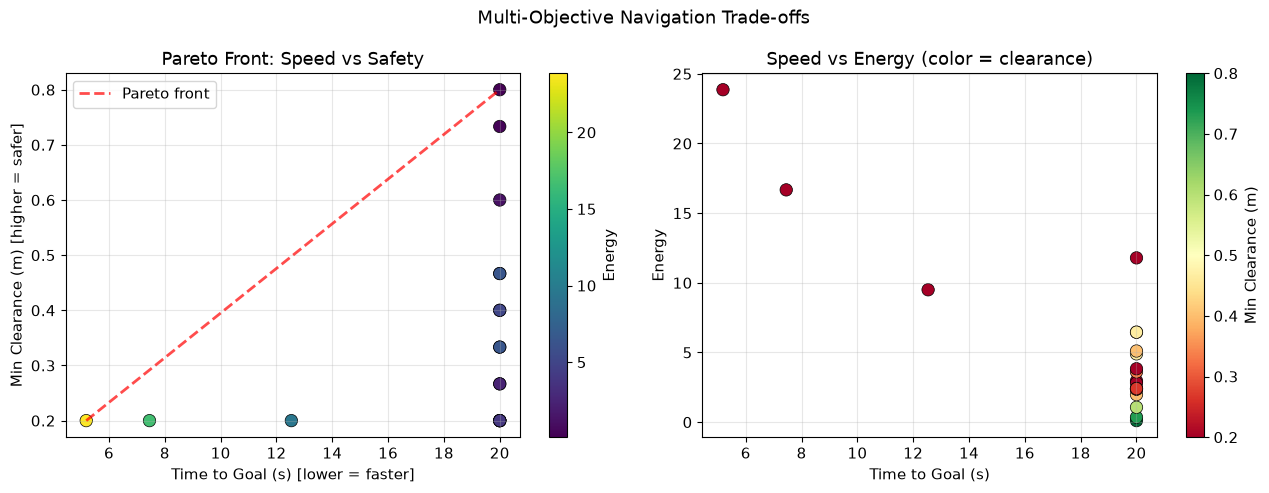


Pareto-optimal configurations: 2 / 20


In [12]:
# --------------------------------------------------------------------------
# Multi-objective navigation: safety vs speed trade-off
# --------------------------------------------------------------------------


def evaluate_navigation_objectives(
    grid: OccupancyGrid3D,
    start: np.ndarray,
    goal: np.ndarray,
    safety_weight: float,
    speed_weight: float,
    n_trials: int = 5,
    max_steps: int = 400,
    dt: float = 0.05,
) -> tuple[float, float, float]:
    """Evaluate navigation with given safety/speed trade-off.

    Returns: (avg_time, avg_min_clearance, avg_energy)
    """
    times: list[float] = []
    clearances: list[float] = []
    energies: list[float] = []

    for trial in range(n_trials):
        rng = np.random.RandomState(trial + 100)
        pos = start + rng.randn(3) * 0.1
        pos[2] = start[2]
        min_clearance = 10.0
        total_energy = 0.0
        reached = False
        # Simulation steps actually consumed, so the completion time below is
        # well-defined for every exit path: goal reached, collision, or budget.
        steps_taken = 0

        for _step in range(max_steps):
            steps_taken += 1
            if np.linalg.norm(pos - goal) < 0.5:
                reached = True
                break

            # Goal direction
            to_goal = goal - pos
            goal_dist = np.linalg.norm(to_goal)
            goal_dir = to_goal / (goal_dist + 1e-8)

            # Check nearby obstacles for clearance
            yaw = np.arctan2(goal_dir[1], goal_dir[0])
            depths, angles = synthesize_depth_from_grid(
                grid, pos, yaw, n_rays=16, fov=np.radians(120)
            )
            d_min = np.min(depths)
            min_clearance = min(min_clearance, d_min)

            # Speed: modulated by safety_weight
            base_speed = speed_weight * 3.0
            safe_speed = base_speed * min(1.0, d_min / (safety_weight * 2.0 + 0.5))

            # Steering: stronger avoidance with higher safety_weight
            repulse = np.zeros(3)
            for d_i, a_i in zip(depths, angles, strict=False):
                if d_i < safety_weight * 2.5 + 0.5:
                    force = (safety_weight * 2.5 + 0.5 - d_i) * safety_weight
                    repulse[0] -= force * np.cos(a_i)
                    repulse[1] -= force * np.sin(a_i)

            vel = safe_speed * goal_dir + 0.3 * repulse
            vel[2] = 2.0 * (start[2] - pos[2])
            vel_norm = np.linalg.norm(vel)
            if vel_norm > base_speed + 0.5:
                vel = vel / vel_norm * (base_speed + 0.5)

            total_energy += np.sum(vel**2) * dt

            new_pos = pos + vel * dt
            if grid.is_free_world(new_pos):
                pos = new_pos
            else:
                break

        completion_time = steps_taken * dt if reached else max_steps * dt
        times.append(float(completion_time))
        clearances.append(float(min_clearance))
        energies.append(float(total_energy))

    return (
        float(np.mean(times)),
        float(np.mean(clearances)),
        float(np.mean(energies)),
    )


# Sweep weight parameters
pareto_grid = create_random_obstacles(
    grid_shape=(50, 50, 10),
    n_obstacles=10,
    obstacle_size_range=(3, 6),
    resolution=0.2,
    origin=np.zeros(3),
    seed=88,
)

p_start = np.array([1.0, 1.0, 1.0])
p_goal = np.array([8.0, 8.0, 1.0])

safety_weights = np.linspace(0.1, 2.0, 8)
speed_weights = np.linspace(0.3, 1.5, 8)

results_time = []
results_clearance = []
results_energy = []
labels = []

print("Sweeping safety vs speed parameters...")
for sw in [0.2, 0.5, 1.0, 1.5, 2.0]:
    for spw in [0.4, 0.7, 1.0, 1.3]:
        t, c, e = evaluate_navigation_objectives(
            pareto_grid, p_start, p_goal, safety_weight=sw, speed_weight=spw, n_trials=3
        )
        results_time.append(t)
        results_clearance.append(c)
        results_energy.append(e)
        labels.append(f"S={sw:.1f},V={spw:.1f}")

results_time = np.array(results_time)
results_clearance = np.array(results_clearance)
results_energy = np.array(results_energy)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(
    results_time,
    results_clearance,
    c=results_energy,
    cmap="viridis",
    s=80,
    edgecolors="black",
    linewidths=0.5,
)
ax.set_xlabel("Time to Goal (s) [lower = faster]")
ax.set_ylabel("Min Clearance (m) [higher = safer]")
ax.set_title("Pareto Front: Speed vs Safety")
plt.colorbar(sc, ax=ax, label="Energy")

# Approximate Pareto front
is_pareto = np.ones(len(results_time), dtype=bool)
for i in range(len(results_time)):
    for j in range(len(results_time)):
        if i == j:
            continue
        if (
            results_time[j] <= results_time[i]
            and results_clearance[j] >= results_clearance[i]
        ) and (
            results_time[j] < results_time[i]
            or results_clearance[j] > results_clearance[i]
        ):
            is_pareto[i] = False
            break

pareto_t = results_time[is_pareto]
pareto_c = results_clearance[is_pareto]
order = np.argsort(pareto_t)
ax.plot(pareto_t[order], pareto_c[order], "r--", lw=2, alpha=0.7, label="Pareto front")
ax.legend()

ax = axes[1]
ax.scatter(
    results_time,
    results_energy,
    c=results_clearance,
    cmap="RdYlGn",
    s=80,
    edgecolors="black",
    linewidths=0.5,
)
ax.set_xlabel("Time to Goal (s)")
ax.set_ylabel("Energy")
ax.set_title("Speed vs Energy (color = clearance)")
plt.colorbar(ax.collections[0], ax=ax, label="Min Clearance (m)")

plt.suptitle("Multi-Objective Navigation Trade-offs", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nPareto-optimal configurations: {np.sum(is_pareto)} / {len(results_time)}")

## Exercises

1. **Visual servoing**: Implement a controller that tracks a moving target
   point using simulated visual feedback (see scaffold below).

2. **Curriculum learning**: Modify the gate-racing environment to start
   with 1 gate and progressively add more as the policy improves.
   Does this accelerate learning compared to training on all gates at once?

3. **Multi-drone exploration**: Extend the frontier-based exploration
   to 2+ drones that coordinate by assigning different frontiers to
   each drone (avoiding redundant coverage).

4. **Uncertainty-aware navigation**: Modify the reactive controller to
   account for depth measurement uncertainty. Instead of using raw
   depth values \(d_i\), use \(d_i - k\sigma_i\) where \(\sigma_i\) is the
   estimated depth uncertainty. Compare conservative vs aggressive policies.

5. **Teacher-student distillation**: Train a "teacher" policy in the
   navigation environment with full state information (no depth rays,
   direct obstacle positions). Then distill it into a "student" that
   only observes depth rays. Compare with direct RL training of the student.

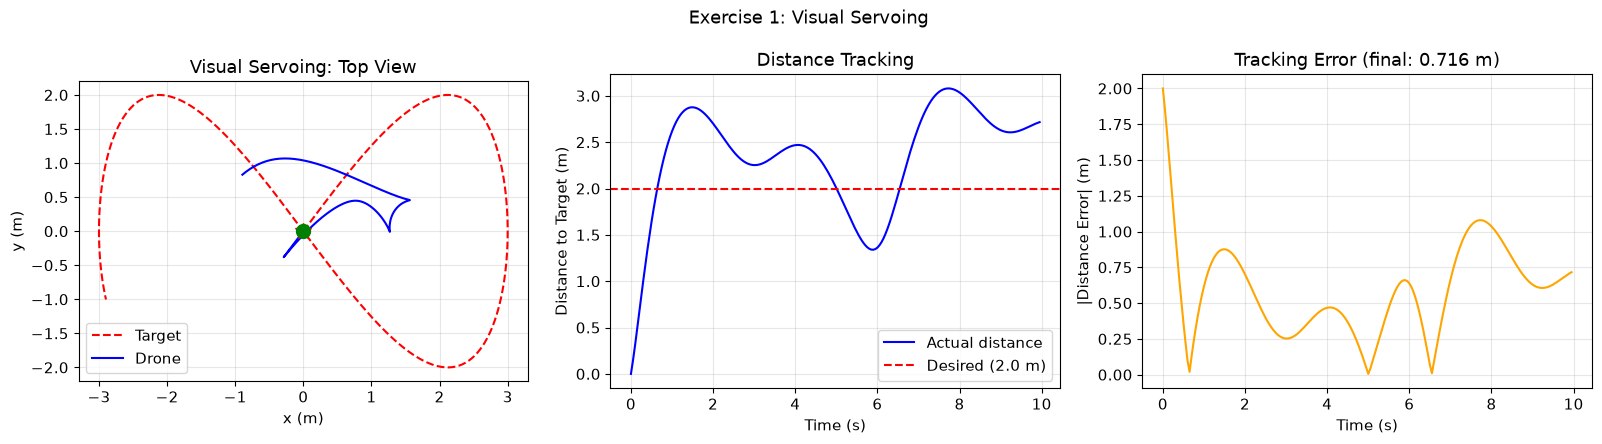

Mean tracking error: 0.590 m
Max tracking error:  2.000 m

Exercise: Replace kinematic model with full quadrotor dynamics
and PID/SE3 controller for realistic visual servoing.


In [13]:
# --------------------------------------------------------------------------
# Exercise 1 scaffold: Visual servoing controller
# --------------------------------------------------------------------------


class VisualServoingController:
    """Track a target point using simulated visual feedback.

    Image-Based Visual Servoing (IBVS): control the drone so that
    the target's projection in the image plane converges to the
    image center.

    The interaction matrix L for a point feature (u, v) at depth Z:
        L = [[-1/Z,  0,   u/Z,  u*v,  -(1+u^2), v ],
             [ 0,   -1/Z, v/Z,  1+v^2,  -u*v,  -u ]]

    We use a simplified 3D position-based approach for clarity.
    """

    kp: float
    kd: float
    max_speed: float
    prev_error: np.ndarray

    def __init__(self, kp: float = 1.5, kd: float = 0.8, max_speed: float = 2.0):
        self.kp = kp
        self.kd = kd
        self.max_speed = max_speed
        self.prev_error = np.zeros(3)

    def compute(
        self,
        drone_pos: np.ndarray,
        drone_vel: np.ndarray,
        target_pos: np.ndarray,
        desired_distance: float = 2.0,
    ) -> np.ndarray:
        """Compute velocity command to maintain desired distance to target."""
        to_target = target_pos - drone_pos
        dist = np.linalg.norm(to_target)
        direction = to_target / (dist + 1e-8)

        # Error: difference between current and desired distance
        distance_error = dist - desired_distance
        error = distance_error * direction

        # PD control
        d_error = error - self.prev_error
        self.prev_error = error.copy()

        vel_cmd = self.kp * error + self.kd * d_error - 0.5 * drone_vel
        speed = np.linalg.norm(vel_cmd)
        if speed > self.max_speed:
            vel_cmd = vel_cmd / speed * self.max_speed

        return vel_cmd


# Simulate visual servoing: drone tracks a moving target
vs_controller = VisualServoingController(kp=1.5, kd=0.8)

dt = 0.05
n_steps = 200
drone_pos = np.array([0.0, 0.0, 1.5])
drone_vel = np.zeros(3)
desired_distance = 2.0

# Target moves in a figure-8 pattern
t_arr = np.arange(n_steps) * dt
target_trajectory = np.column_stack(
    [
        3.0 * np.sin(0.5 * t_arr),
        2.0 * np.sin(1.0 * t_arr),
        1.5 + 0.5 * np.sin(0.3 * t_arr),
    ]
)

drone_positions = [drone_pos.copy()]
tracking_errors = []
distances = []

for i in range(n_steps):
    target_pos = target_trajectory[i]

    vel_cmd = vs_controller.compute(drone_pos, drone_vel, target_pos, desired_distance)

    # Simple kinematic model (Exercise: extend with full QuadrotorState dynamics from NB19)
    drone_vel = 0.8 * drone_vel + 0.2 * vel_cmd
    drone_pos = drone_pos + drone_vel * dt

    drone_positions.append(drone_pos.copy())
    dist_to_target = np.linalg.norm(drone_pos - target_pos)
    tracking_errors.append(abs(dist_to_target - desired_distance))
    distances.append(dist_to_target)

drone_positions = np.array(drone_positions)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(target_trajectory[:, 0], target_trajectory[:, 1], "r--", lw=1.5, label="Target")
ax.plot(drone_positions[:, 0], drone_positions[:, 1], "b-", lw=1.5, label="Drone")
ax.plot(target_trajectory[0, 0], target_trajectory[0, 1], "r*", ms=12)
ax.plot(drone_positions[0, 0], drone_positions[0, 1], "go", ms=10)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Visual Servoing: Top View")
ax.legend()
ax.set_aspect("equal")

ax = axes[1]
ax.plot(t_arr, distances, "b-", lw=1.5, label="Actual distance")
ax.axhline(
    desired_distance,
    color="r",
    ls="--",
    lw=1.5,
    label=f"Desired ({desired_distance} m)",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Distance to Target (m)")
ax.set_title("Distance Tracking")
ax.legend()

ax = axes[2]
ax.plot(t_arr, tracking_errors, "orange", lw=1.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("|Distance Error| (m)")
ax.set_title(f"Tracking Error (final: {tracking_errors[-1]:.3f} m)")

plt.suptitle("Exercise 1: Visual Servoing", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mean tracking error: {np.mean(tracking_errors):.3f} m")
print(f"Max tracking error:  {np.max(tracking_errors):.3f} m")
print("\nExercise: Replace kinematic model with full quadrotor dynamics")
print("and PID/SE3 controller for realistic visual servoing.")


---

## Summary and The Modular vs. End-to-End Debate

This notebook has explored both classical modular pipelines and modern end-to-end
approaches to visual navigation. The field's central tension is:

### Modular: Perceive → Map → Plan → Act

**Strengths**:
- Each module can be independently verified, debugged, and certified
- Safety guarantees can be provided at the planning level (obstacle inflation,
  safe corridors, control barrier functions)
- Modules can be swapped without retraining the whole system
- Failures are interpretable: "the depth was wrong" vs "the planner failed"

**Weaknesses**:
- Information bottleneck at each interface
- Latency accumulates across modules (30–100ms total pipeline delay)
- Suboptimal: locally optimal modules don't compose to globally optimal behavior
- Cannot exploit end-to-end correlations (e.g., motion blur predicts speed)

### End-to-End: Sensors → Actions

**Strengths**:
- No information bottleneck — the network decides what features matter
- Can exploit subtle sensor correlations that modular pipelines discard
- Lower latency (single neural network inference: 5–30ms)
- Can discover superhuman strategies (Kaufmann *et al.*, Nature 2023)

**Weaknesses**:
- No interpretable intermediate representations → hard to debug
- No formal safety guarantees (the network is a black box)
- Requires massive simulation training and careful sim-to-real transfer
- Fails unpredictably in out-of-distribution scenarios

### The 2026 consensus: hybrid architectures

Production autonomous systems (Skydio, DJI, Zipline) use **modular architectures**
with learned components at specific interfaces:

```
Learned Depth → Classical Map → Learned Planner → Classical Controller + Safety Filter
```

This combines the strengths of both: learned perception handles visual complexity,
classical planning provides safety guarantees, and control barrier functions ensure
the system never enters unsafe states regardless of what the planner produces.

The Unified Autonomy Stack (NTNU, 2025) exemplifies this: a factor-graph SLAM
perception module feeds a sampling-based planner (OmniPlanner), with a neural
SDF-NMPC for control and RL-based reactive navigation as a backup. Safety is
guaranteed by control barrier functions that override any upstream decision.

### Key references for further reading

| Paper | Venue | Key contribution |
|---|---|---|
| Loquercio *et al.* | Science Robotics 2021 | Teacher-student sim-to-real for 40 km/h flight |
| Kaufmann *et al.* | Nature 2023 | RL beats human world champions in drone racing |
| SimpleFlight | arXiv 2025 | Five factors for zero-shot PPO sim-to-real |
| RISLAB mono depth | arXiv 2025 | VIO-rescaled monocular depth for collision avoidance |
| ViT obstacle avoidance | arXiv 2024 | Attention-based end-to-end depth-to-control at 7 m/s |
| Event-depth fusion | arXiv 2026 | Cross-attention for 17 m/s obstacle avoidance |
| Unified Autonomy Stack | arXiv 2025 | Full modular stack with CBF safety guarantees |